# What this notebook is doing (Playground)

This notebook is basically my scratchpad.
I used it to try out ideas, inspect datasets, test fixes, and do quick one-off checks before moving cleaner versions of the code into their own notebooks or scripts.

So this file does not follow one single workflow from top to bottom.
It has a mix of experiments around SNOTEL, HRRR, PRISM, CONUS404, ORNL, and other dataset checks, and some cells are clearly intermediate tests rather than final analysis.

If someone opens this notebook later, it is better to treat it as a workbench for exploration and debugging, not as a finished notebook with one final output.


In [17]:
import xarray as xr
from pathlib import Path

data_dir = Path("/data0/balaji24/data/snotel")

all_sites = set()

for zarr_path in data_dir.glob("*_SNOTEL_daily_data.zarr"):
    ds = xr.open_zarr(zarr_path)
    # use `site` not `station`
    sites = ds["site"].values.tolist()
    all_sites.update(sites)

expected_sites = sorted(all_sites)
len(expected_sites), expected_sites

(9,
 ['1080:WA:SNTL',
  '1319:WA:SNTL',
  '711:WA:SNTL',
  '817:WA:SNTL',
  '975:WA:SNTL',
  '990:WA:SNTL',
  '991:WA:SNTL',
  '998:WA:SNTL',
  '999:WA:SNTL'])

In [18]:
site_to_name = {}

for zarr_path in data_dir.glob("*_SNOTEL_daily_data.zarr"):
    ds = xr.open_zarr(zarr_path)
    sites = ds["site"].values.tolist()
    names = ds["site_name"].values.tolist()
    for s, n in zip(sites, names):
        site_to_name.setdefault(s, n)

len(site_to_name), list(site_to_name.items())[:5]

(9,
 [('711:WA:SNTL', 'Rainy Pass'),
  ('817:WA:SNTL', 'Thunder Basin'),
  ('975:WA:SNTL', 'Swamp Creek'),
  ('990:WA:SNTL', 'Beaver Pass'),
  ('991:WA:SNTL', 'Hozomeen Camp')])

In [19]:
import pandas as pd
import xarray as xr
from pathlib import Path

data_dir = Path("/data0/balaji24/data/snotel")

rows = []

for zarr_path in sorted(data_dir.glob("*_SNOTEL_daily_data.zarr")):
    fname = zarr_path.name
    start_date = fname.split("_")[0]   # '2014-01-01'
    year = start_date[:4]
    month = start_date[5:7]

    ds = xr.open_zarr(zarr_path)
    present = set(ds["site"].values.tolist())

    missing = set(expected_sites) - present

    rows.append({
        "year": int(year),
        "month": int(month),
        "present_count": len(present),
        "missing_count": len(missing),
        "missing_sites": sorted(list(missing)),
    })

df = pd.DataFrame(rows)
df.sort_values(["year", "month"], inplace=True)
df

,year,month,present_count,missing_count,missing_sites
0,2014,1,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
1,2014,1,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
2,2014,2,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
3,2014,3,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
4,2014,4,7,2,"[1319:WA:SNTL, 998:WA:SNTL]"
...,...,...,...,...,...
91,2023,5,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
92,2023,6,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
93,2023,7,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"
94,2023,8,6,3,"[1080:WA:SNTL, 1319:WA:SNTL, 998:WA:SNTL]"


In [ ]:
import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

BASE = Path("/data0/balaji24/data")
P_HRRR_DIR = BASE / "weather_data"

def smart_deaccumulate_hrrr_tp(da, time_dim="time", reset_drop_threshold_mm=0.1):
    """
    De-accumulate HRRR total precipitation 'tp' with frequent resets.

    Logic:
    - 'tp' is cumulative within each forecast cycle, then jumps back to ~0 at cycle boundaries.
    - We detect those resets from the time derivative and prevent diffing *across* them.
    - Inside each segment (between resets) we do forward diff and clip negatives to 0.

    Assumes:
      - units are mm or kg m**-2 (≈ mm)
      - dims: (time, y, x) or similar with a 'time' dimension
    """
    # ---- 0. Make sure time is sorted & unique ----
    da = ensure_time_sorted_unique(da)

    if time_dim not in da.dims:
        raise ValueError(f"{time_dim} not in dims: {da.dims}")

    spatial_dims = [d for d in da.dims if d != time_dim]

    # ---- 1. Work in mm (convert meters if needed) ----
    units = str(da.attrs.get("units", "")).lower()
    if units in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"
    elif "kg m" in units and "-2" in units:
        # 1 kg m^-2 ≈ 1 mm
        da.attrs["units"] = "mm"

    # ---- 2. Detect resets from negative jumps in time derivative ----
    diff = da.diff(time_dim, label="upper")  # same dims minus one in time

    if spatial_dims:
        # any grid cell with a big negative drop → treat as cycle reset
        reset_any = (diff < -reset_drop_threshold_mm).any(dim=spatial_dims)
    else:
        reset_any = (diff < -reset_drop_threshold_mm)

    # Build a segment ID per time step:
    # seg_id = 0 for first block, 1 for after first reset, etc.
    seg_ids = np.zeros(da.sizes[time_dim], dtype="int32")
    # align reset_any (length N-1) to time index [1..N-1]
    seg_ids[1:] = np.cumsum(reset_any.values.astype("int32"))
    seg = xr.DataArray(
        seg_ids,
        coords={time_dim: da[time_dim]},
        dims=(time_dim,),
        name="forecast_segment",
    )

    # ---- 3. De-accumulate *within* each segment only ----
    def _deacc_block(block):
        """Diff inside one segment and prepend a 0 at the start."""
        bdiff = block.diff(time_dim, label="upper")
        bdiff = bdiff.where(bdiff >= 0, 0)  # remove small negatives/resets
        # prepend zero at first timestep of this segment
        zero = block.isel({time_dim: slice(0, 1)}) * 0
        out = xr.concat([zero, bdiff], dim=time_dim)
        return out

    inc = da.groupby(seg).map(_deacc_block)
    inc.attrs["units"] = "mm"
    return inc

[SNOTEL] Found 97 monthly zarrs


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


[SNOTEL] Using variable: PRECIPITATION, dims=('time', 'site'), shape=(11654, 9)
[SNOTEL] Raw units='', max=14.2
[SNOTEL] Converting to mm (assumed inches or missing/low units)
[SNOTEL] Stations inside Skagit: 7/9
[SNOTEL] annual_site dims=('year', 'site'), years=[2014 2015 2016 2017 2018 2019 2020]


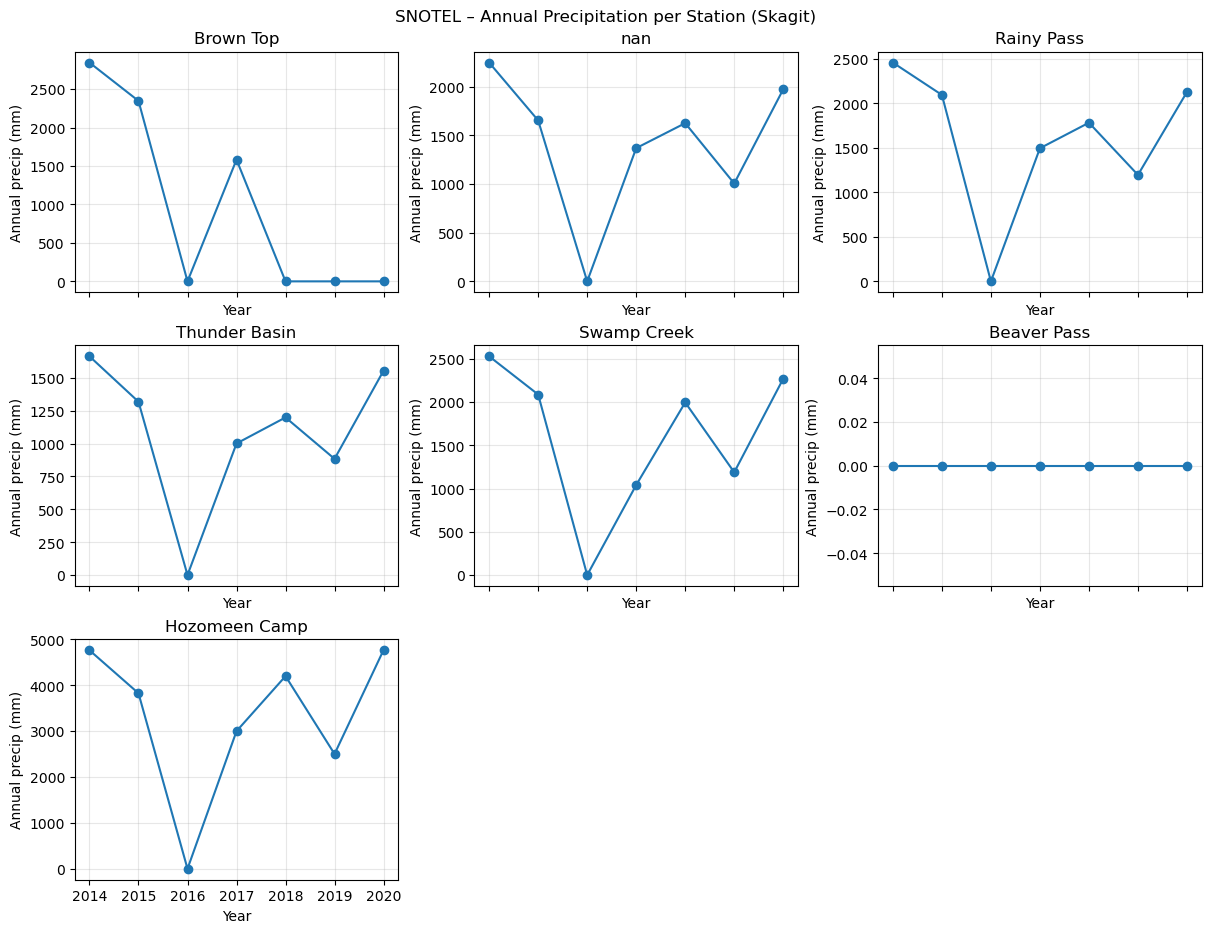

In [ ]:
import os, json
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
P_SNOTEL_DIR = BASE / "snotel"
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = da["time"].values
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)

    if isinstance(obj, dict) and obj.get("type") == "FeatureCollection":
        return shape(obj["features"][0]["geometry"])
    if isinstance(obj, dict) and obj.get("type") == "Feature":
        return shape(obj["geometry"])
    if isinstance(obj, dict) and {"lon", "lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Boundary format not recognized.")

# ---------------- SNOTEL per-station annual totals ----------------
if not P_SNOTEL_DIR.exists():
    raise SystemExit(f"SNOTEL dir not found: {P_SNOTEL_DIR}")

snotel_months = sorted(P_SNOTEL_DIR.glob("**/*.zarr"))
if not snotel_months:
    raise SystemExit("No SNOTEL zarrs found")

print(f"[SNOTEL] Found {len(snotel_months)} monthly zarrs")

# 1) Load all months
dss = xr.concat(
    [safe_open_zarr(p) for p in snotel_months],
    dim="time",
    join="outer",
    coords="minimal",
    compat="override",
)

# 2) Choose precip variable
vS = next(
    (
        v
        for v in [
            "PRECIPITATION",
            "ppt",
            "prcp",
            "ACCUMULATED PRECIPITATION",
            "accum_precip",
        ]
        if v in dss
    ),
    None,
)

if vS is None:
    raise SystemExit("[SNOTEL] No precip variable found")

da = dss[vS]
print(f"[SNOTEL] Using variable: {vS}, dims={da.dims}, shape={da.shape}")

# 3) Units / scale handling
units = str(da.attrs.get("units", "")).lower()
max_val = float(da.max(skipna=True))
print(f"[SNOTEL] Raw units='{units}', max={max_val}")

if (not units) or (units in {"inch", "in", "inches"}) or (max_val <= 10.0):
    da = da * 25.4
    da.attrs["units"] = "mm"
    print("[SNOTEL] Converting to mm (assumed inches or missing/low units)")
else:
    if not units:
        da.attrs["units"] = "mm"

# 4) Restrict to Skagit stations (lat/lon in basin), but KEEP site dimension
site_dim = "site" if "site" in da.dims else None
if site_dim and ("lat" in dss.coords) and ("lon" in dss.coords):
    import shapely.geometry as sgeom

    geom = _load_boundary_geom()
    lats = dss["lat"].values
    lons = dss["lon"].values

    inside = []
    for i in range(len(lats)):
        pt = sgeom.Point(float(lons[i]), float(lats[i]))
        inside.append(geom.contains(pt))

    inside = np.array(inside, dtype=bool)
    print(f"[SNOTEL] Stations inside Skagit: {inside.sum()}/{inside.size}")
    if inside.any():
        da = da.isel({site_dim: np.where(inside)[0]})

# 5) Clean time + restrict to study years (boolean mask to avoid the KeyError)
da = ensure_time_sorted_unique(da)
if "time" in da.dims:
    t = da["time"]
    mask = (t >= np.datetime64(f"{YEAR_MIN}-01-01")) & (t <= np.datetime64(f"{YEAR_MAX}-12-31"))
    da = da.sel(time=mask)

# 6) Daily totals (if sub-daily, this aggregates; if daily, it's a no-op sum)
daily = da.resample(time="1D").sum()

# 7) Annual totals per station
annual_site = daily.groupby("time.year").sum("time")
if "time.year" in annual_site.coords:
    annual_site = annual_site.rename({"time.year": "year"})
years = annual_site["year"].values
print(f"[SNOTEL] annual_site dims={annual_site.dims}, years={years}")

# 8) Station names
if site_dim and "site_name" in dss:
    names = dss["site_name"].values
elif site_dim and "stationTriplet" in dss:
    names = dss["stationTriplet"].values
else:
    if site_dim:
        names = [f"site {i}" for i in range(annual_site.sizes[site_dim])]
    else:
        names = ["SNOTEL"]

# 9) Plot per-station
if site_dim:
    n_sites = annual_site.sizes[site_dim]
    ncols = 3
    nrows = int(np.ceil(n_sites / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 3 * nrows),
        sharex=True,
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    for i in range(n_sites):
        ax = axes[i]
        series_i = annual_site.isel({site_dim: i})

        ax.plot(years, series_i.values, marker="o")
        ax.set_title(str(names[i]))
        ax.set_xlabel("Year")
        ax.set_ylabel("Annual precip (mm)")
        ax.grid(alpha=0.3)

    for j in range(n_sites, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("SNOTEL – Annual Precipitation per Station (Skagit)", y=1.02)
    plt.show()
else:
    plt.figure(figsize=(6, 4))
    plt.plot(years, annual_site.values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Annual precip (mm)")
    plt.title("SNOTEL – Annual Precipitation (single series)")
    plt.grid(alpha=0.3)
    plt.show()

In [22]:
!pip install intake intake-xarray requests aiohttp

In [23]:
!pip install s3fs

In [ ]:
# ===============================================================
# Download CONUS404 DRB precip (2015) from HyTEST
# conus404_drb_precip_2015.nc (incremental precip)
# ===============================================================

# --- Install deps (safe to re-run) ---
import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs pandas

# --- Imports ---
import intake
import xarray as xr
import pandas as pd
from pathlib import Path

print("✓ Imports & installations complete")

# --- 1. Open HyTEST intake catalog ---
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
print("✓ Catalog opened")

# --- 2. Access DRB subcatalog ---
conus_subcat = cat["conus404-drb-eval-tutorial-catalog"]
print("✓ Subcatalog loaded")

# --- 3. Load DRB CONUS404 dataset from OSN ---
ds = conus_subcat["conus404-drb-OSN"].to_dask()
print("✓ Loaded CONUS404 DRB dataset from OSN")

# --- 4. Extract 2015 cumulative precipitation ---
var_name = "PREC_ACC_NC"
precip_2015 = ds[var_name].sel(time=slice("2015-01-01", "2015-12-31"))
print("✓ Extracted PREC_ACC_NC for 2015")

# --- 5. Convert cumulative to incremental precipitation ---
precip_inc = (
    precip_2015
    .sortby("time")
    .diff("time", label="lower")
    .where(lambda x: x >= 0)
)
print("✓ Converted to incremental precipitation")

# --- 6. Save the result ---
outfile = Path("conus404_drb_precip_2015.nc")
precip_inc.to_dataset(name="PRECIP_INC").to_netcdf(outfile)
print(f"✓ Saved reference file: {outfile.resolve()}")

# --- 7. Final confirmation ---
xr.open_dataset(outfile)

✓ Imports & installations complete
✓ Catalog opened
✓ Subcatalog loaded
✓ Loaded CONUS404 DRB dataset from OSN
✓ Extracted PREC_ACC_NC for 2015
✓ Converted to incremental precipitation


PermissionError: [Errno 13] Permission denied: '/home/balaji24/skagit-met/analysis/conus404_drb_precip_2015.nc'

✓ Loaded conus404-daily-osn
✓ Selected PREC_ACC_NC for 2014–2020
✓ Loaded Skagit boundary
✓ Built Skagit mask
✓ Computed basin-mean daily precip
Annual totals (mm):
2014: 2650.3 mm
2015: 2102.4 mm
2016: 2415.3 mm
2017: 2318.6 mm
2018: 2312.8 mm
2019: 1587.5 mm
2020: 2605.2 mm


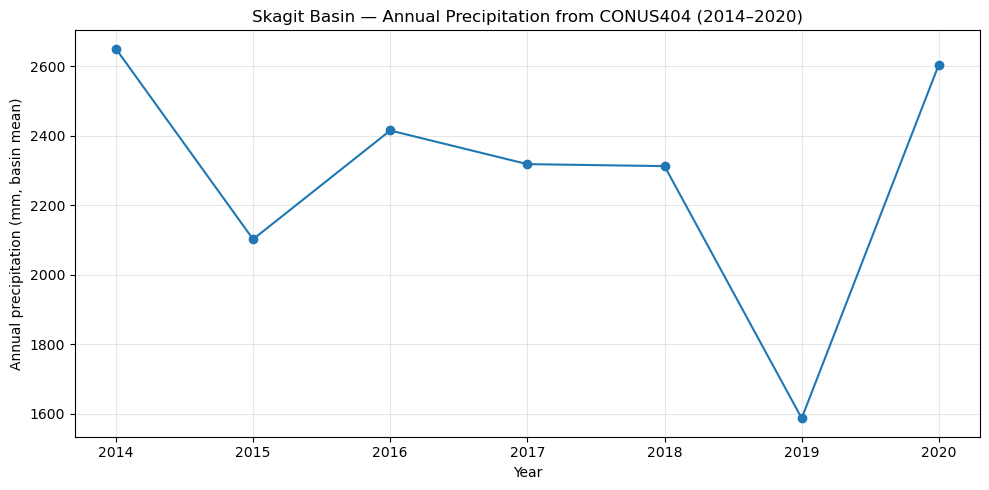

In [ ]:
# ================================================
# Skagit Basin — Annual Precipitation from CONUS404
# (2014–2020, using PREC_ACC_NC)
# ================================================

import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs geopandas shapely matplotlib

import intake
import xarray as xr
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

# 1) Open CONUS404 daily dataset
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
print("✓ Loaded conus404-daily-osn")

# 2) Select precip + time range
var = "PREC_ACC_NC"
if var not in ds.data_vars:
    raise KeyError(f"{var} not found in dataset")

precip = ds[var].sel(time=slice("2014-01-01", "2020-12-31"))
print("✓ Selected PREC_ACC_NC for 2014–2020")

# 3) Load Skagit boundary and build mask (lat/lon are already 2D)
skagit_geo = "../data/GIS/SkagitBoundary.json"  
gdf = gpd.read_file(skagit_geo)
geom = gdf.geometry.iloc[0]
print("✓ Loaded Skagit boundary")

lat = ds["lat"]
lon = ds["lon"]
mask_np = shapely.contains_xy(geom, lon.values, lat.values)   # shape (y, x)
mask_da = xr.DataArray(mask_np, dims=("y", "x"))
print("✓ Built Skagit mask")

# 4) Basin-mean daily precip time series
precip_skagit = precip.where(mask_da)
skagit_daily = precip_skagit.mean(dim=("y", "x"))
print("✓ Computed basin-mean daily precip")

# 5) Annual totals (mm per year, basin mean)
skagit_annual = skagit_daily.resample(time="YS").sum()   # YS = year start
years = skagit_annual["time"].dt.year.values
values = skagit_annual.values

print("Annual totals (mm):")
for y, v in zip(years, values):
    print(f"{y}: {float(v):.1f} mm")

# 6) Plot like your example (one line)
plt.figure(figsize=(10, 5))
plt.plot(years, values, marker="o")
plt.title("Skagit Basin — Annual Precipitation from CONUS404 (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

✓ Loaded conus404-daily-osn
✓ Selected PREC_ACC_NC for 2014–2020
✓ Loaded Skagit boundary
✓ Built Skagit mask
✓ Computed basin-mean daily precip
Annual totals (mm):
2014: 2650.3 mm
2015: 2102.4 mm
2016: 2415.3 mm
2017: 2318.6 mm
2018: 2312.8 mm
2019: 1587.5 mm
2020: 2605.2 mm


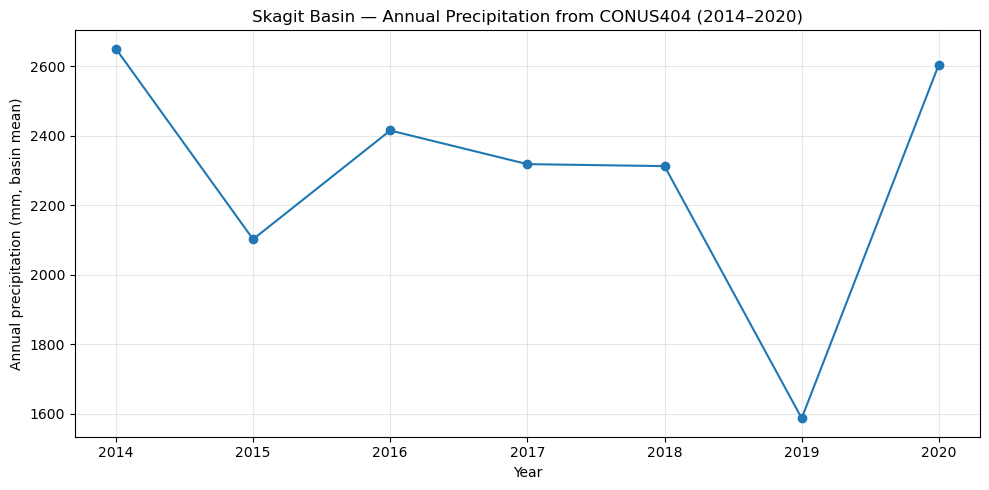

In [ ]:
# ================================================
# Skagit Basin — Annual Precipitation from CONUS404
# (2014–2020, using PREC_ACC_NC)
# ================================================

import sys
!{sys.executable} -m pip install -q intake intake-xarray xarray zarr fsspec s3fs geopandas shapely matplotlib

import intake
import xarray as xr
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt

# 1) Open CONUS404 daily dataset
url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
cat = intake.open_catalog(url)
ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
print("✓ Loaded conus404-daily-osn")

# 2) Select precip + time range
var = "PREC_ACC_NC"
if var not in ds.data_vars:
    raise KeyError(f"{var} not found in dataset")

precip = ds[var].sel(time=slice("2014-01-01", "2020-12-31"))
print("✓ Selected PREC_ACC_NC for 2014–2020")

# 3) Load Skagit boundary and build mask (lat/lon are already 2D)
skagit_geo = "../data/GIS/SkagitBoundary.json"  
gdf = gpd.read_file(skagit_geo)
geom = gdf.geometry.iloc[0]
print("✓ Loaded Skagit boundary")

lat = ds["lat"]
lon = ds["lon"]
mask_np = shapely.contains_xy(geom, lon.values, lat.values)   # shape (y, x)
mask_da = xr.DataArray(mask_np, dims=("y", "x"))
print("✓ Built Skagit mask")

# 4) Basin-mean daily precip time series
precip_skagit = precip.where(mask_da)
skagit_daily = precip_skagit.mean(dim=("y", "x"))
print("✓ Computed basin-mean daily precip")

# 5) Annual totals (mm per year, basin mean)
skagit_annual = skagit_daily.resample(time="YS").sum()   # YS = year start
years = skagit_annual["time"].dt.year.values
values = skagit_annual.values

print("Annual totals (mm):")
for y, v in zip(years, values):
    print(f"{y}: {float(v):.1f} mm")

# 6) Plot like your example (one line)
plt.figure(figsize=(10, 5))
plt.plot(years, values, marker="o")
plt.title("Skagit Basin — Annual Precipitation from CONUS404 (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total stations with CSV data: 969
                        name network  elevation_m   latitude   longitude  \
code                                                                       
301_CA_SNTL         Adin Mtn  SNOTEL  1886.712036  41.235828 -120.791924   
907_UT_SNTL      Agua Canyon  SNOTEL  2712.719971  37.522171 -112.271179   
916_MT_SNTL       Albro Lake  SNOTEL  2529.840088  45.597229 -111.959023   
1267_AK_SNTL  Alexander Lake  SNOTEL    48.768002  61.749668 -150.889664   
908_WA_SNTL   Alpine Meadows  SNOTEL  1066.800049  47.779572 -121.698471   

                   state           HUC   mgrs  \
code                                            
301_CA_SNTL   California  180200021403  10TFL   
907_UT_SNTL         Utah  160300020301  12SUG   
916_MT_SNTL      Montana  100200050701  12TVR   
1267_AK_SNTL      Alaska  190205051106  05VPJ   
908_WA_SNTL   Washington  171100100501  10TET   

                                mountainRange  beginDate    endDate  csvData  \
code     

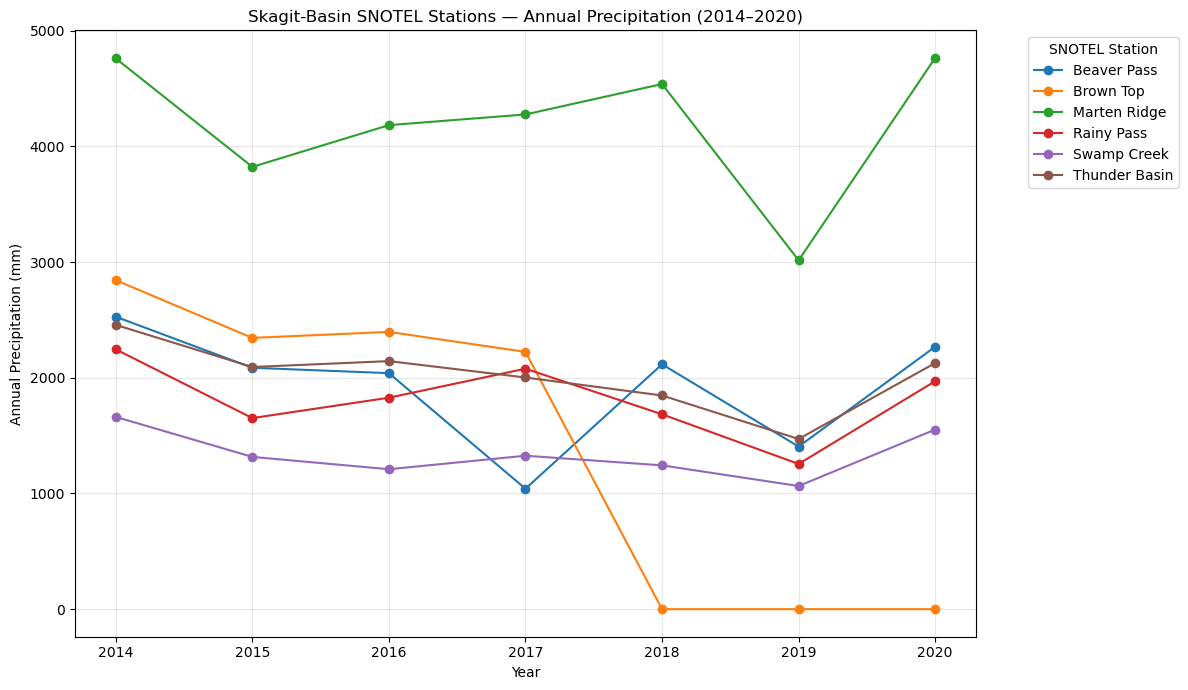


Mean SNOTEL annual precipitation (mm) by year:
year
2014    2749.950000
2015    2219.550000
2016    2300.700000
2017    2158.450000
2018    1905.300000
2019    1368.800000
2020    2114.483333
dtype: float64


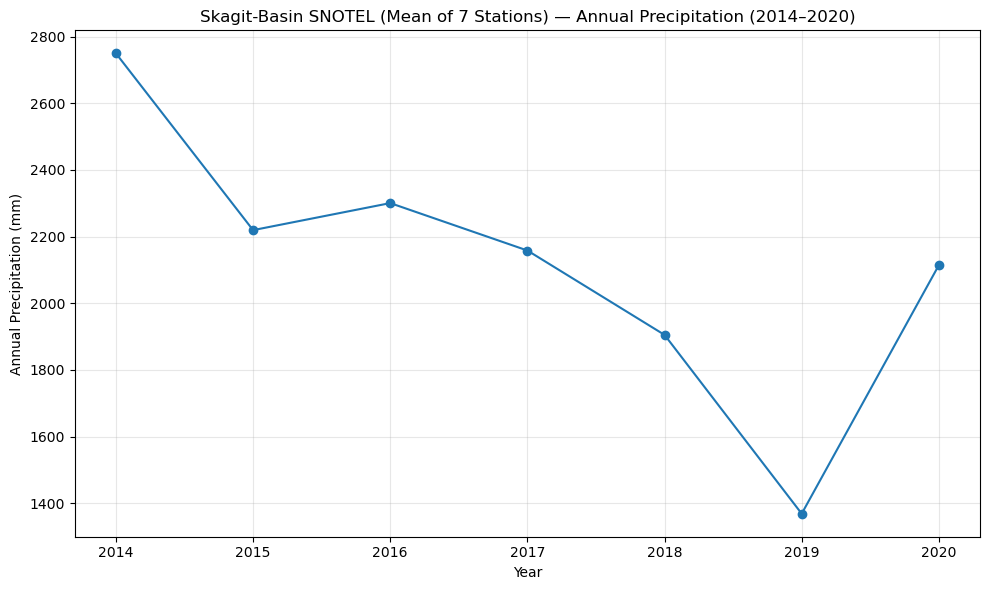

In [16]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SNOTEL_BASE = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main"

# 1) Load all stations (GeoJSON from GitHub)
stations = (
    gpd.read_file(f"{SNOTEL_BASE}/all_stations.geojson")
    .set_index("code")
)
stations = stations[stations["csvData"] == True]  # only stations with data

print("Total stations with CSV data:", len(stations))
print(stations.head())

# 2) Select the specific 7 stations by name
desired_names = [
    "Brown Top",
    "Rainy Pass",
    "Thunder Basin",
    "Swamp Creek",
    "Beaver Pass",
    "Hozomeen Camp",
    "Marten Ridge",
]

chosen = stations[stations["name"].isin(desired_names)].copy()
print("\nChosen stations:")
print(chosen[["name", "state", "elevation_m"]])

# 3) Loop over each station, read its CSV from GitHub, compute annual precip
rows = []
YEAR_MIN, YEAR_MAX = 2014, 2020

for code, row in chosen.iterrows():
    name = row["name"]
    csv_url = f"{SNOTEL_BASE}/data/{code}.csv"
    print(f"\nLoading {name} ({code}) from {csv_url}")

    df = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)

    # PRCPSA is daily accumulated precipitation [m] in this repo
    if "PRCPSA" not in df.columns:
        print(f"  -> No PRCPSA column for {name}, skipping")
        continue

    # convert m -> mm
    df["PRCPSA_mm"] = df["PRCPSA"] * 1000.0

    # keep 2014–2020 and sum by year
    df_sel = df.loc[f"{YEAR_MIN}-01-01": f"{YEAR_MAX}-12-31"]
    ann = df_sel["PRCPSA_mm"].groupby(df_sel.index.year).sum()

    for year, mm in ann.items():
        rows.append(
            {"station": name, "year": int(year), "mm": float(mm)}
        )

# 4) Build DataFrame and pivot for plotting
annual_df = pd.DataFrame(rows)
annual_df = annual_df[
    (annual_df["year"] >= YEAR_MIN) & (annual_df["year"] <= YEAR_MAX)
].copy()

print("\nAnnual precipitation table:")
print(annual_df.head())

pivot = annual_df.pivot(index="year", columns="station", values="mm").sort_index()

# 5) Plot, one line per station
plt.figure(figsize=(12, 7))

for station in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[station],
        marker="o",
        label=station,
    )

plt.title("Skagit-Basin SNOTEL Stations — Annual Precipitation (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual Precipitation (mm)")
plt.grid(True, alpha=0.3)
plt.legend(title="SNOTEL Station", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# pivot: index = year, columns = station, values = annual precip (mm)
# -------------------------------------------
# 1) Compute mean across all SNOTEL stations for each year
snotel_mean = pivot.mean(axis=1)   # one value per year

print("\nMean SNOTEL annual precipitation (mm) by year:")
print(snotel_mean)

# 2) Plot as a single SNOTEL curve
plt.figure(figsize=(10, 6))
plt.plot(snotel_mean.index, snotel_mean.values, marker="o")
plt.title("Skagit-Basin SNOTEL (Mean of 7 Stations) — Annual Precipitation (2014–2020)")
plt.xlabel("Year")
plt.ylabel("Annual Precipitation (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Found 97 SNOTEL zarrs


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


Using SNOTEL variable: PRECIPITATION
Loaded Skagit boundary
Total stations: 9, in Skagit: 7
Annual shape: (7, 7)
      Brown Top  Rainy Pass  Thunder Basin  Swamp Creek  Beaver Pass  \
2014    2844.80     2247.90        2458.72      1663.70      2529.84   
2015    2346.96     1653.54        2095.50      1318.26      2087.88   
2016       0.00        0.00           0.00         0.00         0.00   
2017    1582.42     1369.06        1496.06      1000.76      1041.40   
2018       0.00     1625.60        1783.08      1198.88      1996.44   
2019       0.00     1005.84        1196.34       883.92      1188.72   
2020       0.00     1973.58        2128.52      1554.48      2270.76   

      Hozomeen Camp  Marten Ridge  
2014            0.0       4762.50  
2015            0.0       3825.24  
2016            0.0          0.00  
2017            0.0       2999.74  
2018            0.0       4198.62  
2019            0.0       2501.90  
2020            0.0       4767.58  


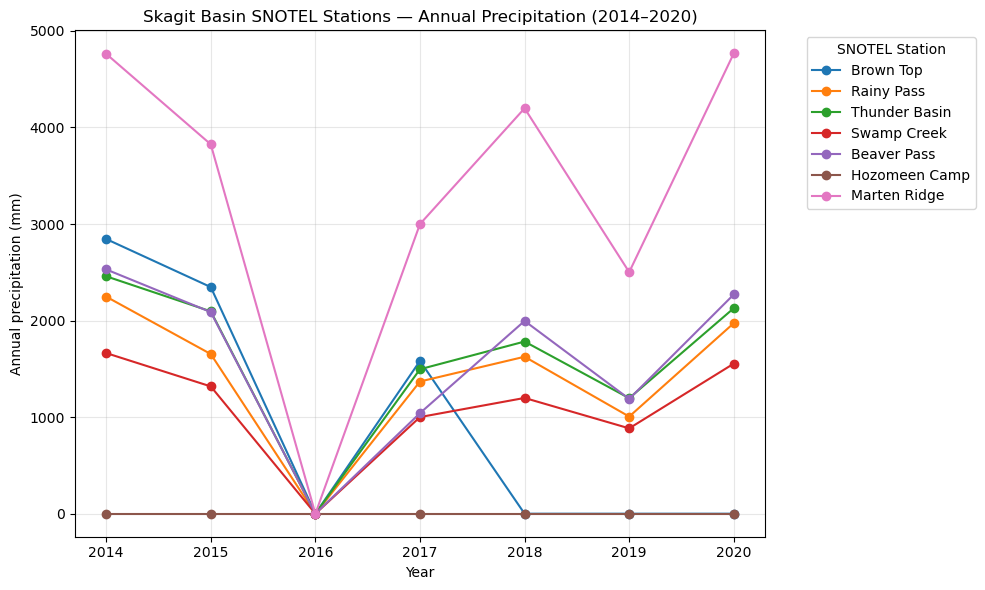

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import shapely.geometry as sgeom

# ---------------- Paths ----------------
BASE = Path("/data0/balaji24/data")
P_SNOTEL_DIR = BASE / "snotel"               
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2020

# ---------------- Helpers ----------------
def _load_boundary_geom():
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)

    from shapely.geometry import shape, Polygon, LinearRing

    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Load SNOTEL ----------------
snotel_months = sorted(P_SNOTEL_DIR.glob("**/*.zarr"))
if not snotel_months:
    raise FileNotFoundError("No SNOTEL zarrs found under /data0/balaji24/data/snotel")

print(f"Found {len(snotel_months)} SNOTEL zarrs")
dss = xr.concat(
    [xr.open_zarr(p, consolidated=False) for p in snotel_months],
    dim="time",
    join="outer",
    coords="minimal",
    compat="override",
)

# Pick precip variable
vS = next(
    (v for v in ["PRECIPITATION", "ppt", "prcp", "ACCUMULATED PRECIPITATION", "accum_precip"]
     if v in dss),
    None
)
if vS is None:
    raise KeyError(f"No precip-like var found in SNOTEL dataset. Got: {list(dss.data_vars)}")

da = dss[vS]
print("Using SNOTEL variable:", vS)

# Units → mm
units = str(da.attrs.get("units", "")).lower()
# Heuristic: inches or missing / very small magnitudes
if (not units) or (units in {"inch", "in", "inches"}) or (float(da.max()) <= 10.0):
    da = da * 25.4
    da.attrs["units"] = "mm"

# ---------------- Filter stations inside Skagit ----------------
geom = _load_boundary_geom()
print("Loaded Skagit boundary")

if ("lat" not in dss.coords) or ("lon" not in dss.coords):
    raise KeyError("SNOTEL dataset missing lat/lon coords for stations")

lats = dss["lat"].values
lons = dss["lon"].values

inside_idx = []
for i in range(len(lats)):
    pt = sgeom.Point(float(lons[i]), float(lats[i]))
    inside_idx.append(geom.contains(pt))

inside_idx = np.array(inside_idx)
print(f"Total stations: {len(lats)}, in Skagit: {inside_idx.sum()}")

if inside_idx.sum() == 0:
    raise RuntimeError("No SNOTEL stations found inside Skagit polygon.")

# Subset data to Skagit stations only
site_dim = "site" if "site" in da.dims else da.dims[1]  # crude but works for (time, site)
da_s = da.isel({site_dim: np.where(inside_idx)[0]})

# Try to get a label per station: either a site name or use index
if "site_name" in dss:
    station_labels = dss["site_name"].isel({site_dim: np.where(inside_idx)[0]}).values
else:
    station_labels = np.array([f"site_{i}" for i in np.where(inside_idx)[0]])

# ---------------- Compute annual precip per station ----------------
da_s = ensure_time_sorted_unique(da_s)

# If data are sub-daily / monthly, this still normalizes to daily totals
daily = da_s.resample(time="1D").sum()

# Restrict to study period
daily = daily.sel(time=slice(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))

# Group by year and sum to mm/year per station
annual = daily.groupby("time.year").sum("time")  # dims: year, site
annual = annual.rename({"year": "year"})
print("Annual shape:", annual.shape)

years = annual["year"].values

# Build a DataFrame: rows = years, columns = stations
df_list = []
for j in range(annual.sizes[site_dim]):
    series = annual.isel({site_dim: j})
    vals = series.values
    df_list.append(pd.Series(vals, index=years, name=str(station_labels[j])))

df_annual = pd.concat(df_list, axis=1)
print(df_annual)

# ---------------- Plot: 1 line per SNOTEL station ----------------
plt.figure(figsize=(10, 6))
for col in df_annual.columns:
    plt.plot(df_annual.index, df_annual[col], marker="o", label=col)

plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm)")
plt.title("Skagit Basin SNOTEL Stations — Annual Precipitation (2014–2020)")
plt.grid(True, alpha=0.3)
plt.legend(title="SNOTEL Station", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
import xarray as xr
import geopandas as gpd
import shapely
import numpy as np
from pathlib import Path

# ----------------------------
# Load PRISM 800m 2014 dataset
# ----------------------------
zarr_path = Path("/data0/balaji24/data/prism_ppt_800m/2014-01-01_2014-12-31_daily_800m_PRISM_data.zarr")
ds = xr.open_zarr(zarr_path)

ppt = ds["ppt"]   # (time, lat, lon), units: mm/day
lat = ds["lat"]
lon = ds["lon"]

# ----------------------------
# Load Skagit Basin boundary
# ----------------------------
boundary_path = "/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json"
gdf = gpd.read_file(boundary_path)
geom = gdf.geometry.iloc[0]   # shapely polygon

# ----------------------------
# Build 2D mask for basin
# ----------------------------
lon2d, lat2d = np.meshgrid(lon.values, lat.values)      # shape (lat, lon)
mask_np = shapely.contains_xy(geom, lon2d, lat2d)       # same shape (lat, lon)
mask_da = xr.DataArray(mask_np, dims=("lat", "lon"))

# ----------------------------
# Compute basin-mean daily precip
# ----------------------------
ppt_masked = ppt.where(mask_da)
daily_mean = ppt_masked.mean(dim=("lat", "lon"))        # mm/day (dask array)

# ----------------------------
# Annual total (mm)
# ----------------------------
annual_2014_mm = float(daily_mean.sum().compute())      # compute() instead of .item()

print("=======================================")
print(" Skagit Basin — PRISM 800m Annual Precip (2014)")
print("=======================================")
print(f" Total Precipitation: {annual_2014_mm:.2f} mm")
print("=======================================")

 Skagit Basin — PRISM 800m Annual Precip (2014)
 Total Precipitation: 2941.22 mm



=== 2016 Basin-mean annual precip (mm) ===
PRISM 4km : 2306.6 mm
HRRR      : 1565.2 mm



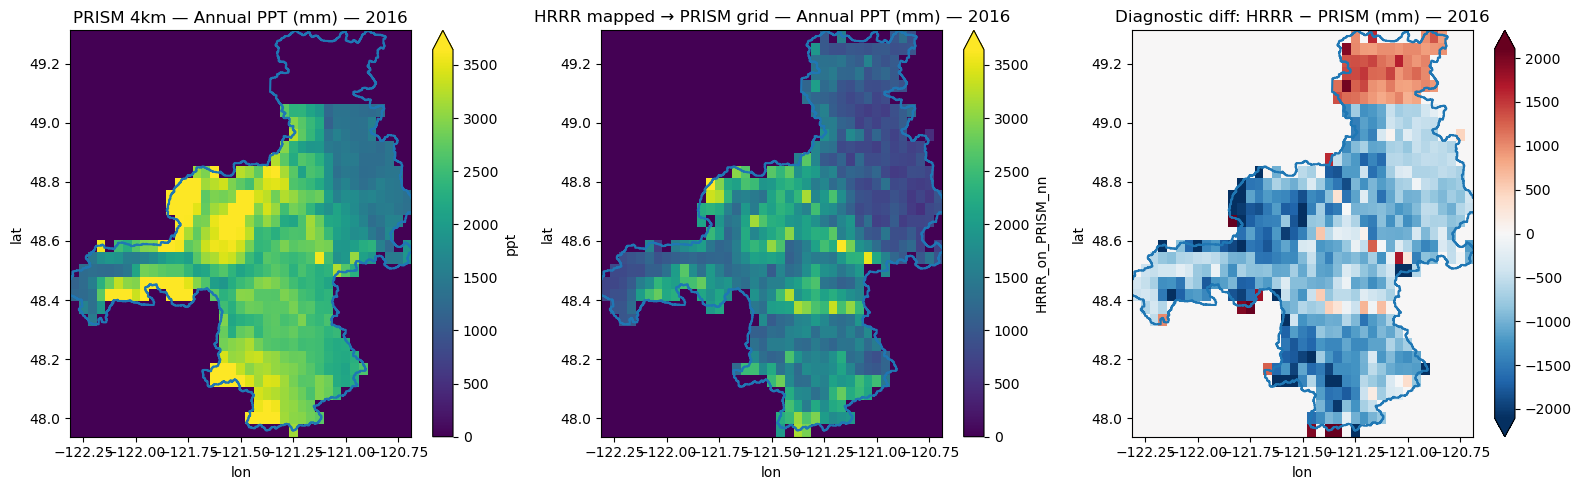

In [ ]:
# ============================
# HRRR vs PRISM — Spatial comparison for one year (Skagit region)
# Produces: PRISM annual map, HRRR annual map (STRAIGHT via PRISM grid), HRRR-PRISM diff map
# Uses local zarrs:
#   PRISM: /data0/balaji24/data/prism_ppt/**/*_daily_4km_PRISM_data.zarr
#   HRRR : /data0/balaji24/data/weather_data/YYYY-MM_HRRR_data.zarr
# ============================

import re, json
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"

YEAR = 2016 

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path) -> xr.Dataset:
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def ensure_time_sorted_unique(da: xr.DataArray) -> xr.DataArray:
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def deaccumulate_generic(da: xr.DataArray, time_dim="time", clip_zero=True) -> xr.DataArray:
    """Turn cumulative -> per-step increments. Works with time or (run/step)."""
    run_coord  = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)

    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds: xr.Dataset, var: str) -> xr.DataArray:
    """Return hourly precip increments (mm). Auto-detect cumulative vs incremental."""
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def load_skagit_geom():
    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and obj.get("type") == "FeatureCollection":
        return shape(obj["features"][0]["geometry"])
    if isinstance(obj, dict) and obj.get("type") == "Feature":
        return shape(obj["geometry"])
    return shape(obj)

def polygon_outline_xy(geom):
    x, y = geom.exterior.xy
    return np.asarray(x), np.asarray(y)

def subset_bbox(da, lat_name="lat", lon_name="lon", pad=0.2):
    """Subset to Skagit bbox +/- pad degrees (PRISM only)."""
    geom = load_skagit_geom()
    minx, miny, maxx, maxy = geom.bounds  # lon/lat
    return da.sel(
        {lat_name: slice(miny - pad, maxy + pad),
         lon_name: slice(minx - pad, maxx + pad)}
    )

# ---------------- Load PRISM ----------------
prism_zarrs = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
if not prism_zarrs:
    raise FileNotFoundError(f"No PRISM zarrs found under {P_PRISM_DIR}")

dsp = xr.concat([safe_open_zarr(p) for p in prism_zarrs],
                dim="time", join="outer", coords="minimal", compat="override")
v_prism = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
if v_prism is None:
    raise KeyError("PRISM precip var not found. Expected one of: ppt/precip/prcp")

prism = ensure_time_sorted_unique(dsp[v_prism]).sel(time=slice(f"{YEAR}-01-01", f"{YEAR}-12-31"))
prism = subset_bbox(prism, lat_name="lat", lon_name="lon", pad=0.25)
prism_ann = prism.sum("time", skipna=True)  # (lat, lon)

# ---------------- Load HRRR ----------------
months = sorted(P_HRRR_DIR.glob(f"{YEAR}-??_HRRR_data.zarr"))
if not months:
    raise FileNotFoundError(f"No HRRR monthly zarrs found for {YEAR} under {P_HRRR_DIR}")

dsh_list = [safe_open_zarr(p) for p in months]
dsh = xr.concat(dsh_list, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

v_hrrr = "tp" if "tp" in dsh else ("apcp" if "apcp" in dsh else None)
if v_hrrr is None:
    raise KeyError("HRRR precip var not found. Expected tp or apcp.")

hrrr_hourly = hrrr_hourly_precip_mm(dsh, var=v_hrrr)
hrrr_daily  = hrrr_hourly.resample(time="1D").sum(skipna=True).sel(time=slice(f"{YEAR}-01-01", f"{YEAR}-12-31"))
hrrr_ann = hrrr_daily.sum("time", skipna=True)  # native HRRR grid (tilted if plotted in lon/lat)

# ---------------- Skagit outline & PRISM mask (for means) ----------------
from shapely import contains_xy
geom = load_skagit_geom()
sx, sy = polygon_outline_xy(geom)

lon2d, lat2d = np.meshgrid(prism_ann["lon"].values, prism_ann["lat"].values)
mask_prism = contains_xy(geom, lon2d, lat2d)
prism_basin_mean_mm = float(prism_ann.where(mask_prism).mean(("lat","lon"), skipna=True).compute())

# ---------------- Find HRRR 2D lat/lon ----------------
lat_h = None
lon_h = None
for cand in ["lat","latitude","XLAT","XLAT_M"]:
    if cand in dsh:
        lat_h = dsh[cand]
        break
for cand in ["lon","longitude","XLONG","XLONG_M"]:
    if cand in dsh:
        lon_h = dsh[cand]
        break

if lat_h is None or lon_h is None:
    print("[WARN] HRRR lat/lon not found; cannot build straight HRRR plot on PRISM grid.")
    lat_h2 = lon_h2 = None
    hrrr_on_prism = None
    hrrr_basin_mean_mm = np.nan
else:
    lat_h2 = lat_h.isel(time=0) if "time" in lat_h.dims else lat_h
    lon_h2 = lon_h.isel(time=0) if "time" in lon_h.dims else lon_h
    mask_hrrr = contains_xy(geom, lon_h2.values, lat_h2.values)
    hrrr_basin_mean_mm = float(hrrr_ann.where(mask_hrrr).mean(hrrr_ann.dims, skipna=True).compute())

    # ---------------- Build diagnostic HRRR->PRISM mapping (STRAIGHT) ----------------
    # NOTE: This is diagnostic nearest-neighbor on flattened lat/lon (fast, not “true regridding”).
    h_lat = lat_h2.values.reshape(-1)
    h_lon = lon_h2.values.reshape(-1)
    h_val = hrrr_ann.values.reshape(-1)

    p_lat = lat2d.reshape(-1)
    p_lon = lon2d.reshape(-1)

    out = np.full(p_lat.shape, np.nan, dtype="float32")
    chunk = 2000
    for i in range(0, p_lat.size, chunk):
        j = min(i + chunk, p_lat.size)
        d2 = (h_lat[:, None] - p_lat[i:j][None, :])**2 + (h_lon[:, None] - p_lon[i:j][None, :])**2
        idx = np.argmin(d2, axis=0)
        out[i:j] = h_val[idx].astype("float32")

    hrrr_on_prism = xr.DataArray(
        out.reshape(lat2d.shape),
        dims=("lat","lon"),
        coords={"lat": prism_ann["lat"], "lon": prism_ann["lon"]},
        name="HRRR_on_PRISM_nn",
    )

print(f"\n=== {YEAR} Basin-mean annual precip (mm) ===")
print(f"PRISM 4km : {prism_basin_mean_mm:.1f} mm")
print(f"HRRR      : {hrrr_basin_mean_mm:.1f} mm")
print("==========================================\n")

# ---------------- Shared color scale (PRISM + HRRR_on_prism) ----------------
if hrrr_on_prism is None:
    raise RuntimeError("Cannot plot HRRR straight: hrrr_on_prism could not be constructed (missing HRRR lat/lon).")

combined = xr.concat([prism_ann.astype("float32"), hrrr_on_prism.astype("float32")], dim="stack")
vmin = float(combined.quantile(0.02).compute())
vmax = float(combined.quantile(0.98).compute())
cmap_main = "viridis"

# ---------------- Plot (ALL STRAIGHT) ----------------
plt.figure(figsize=(16, 5))

# PRISM
ax1 = plt.subplot(1, 3, 1)
prism_ann.plot(ax=ax1, x="lon", y="lat", vmin=vmin, vmax=vmax, cmap=cmap_main, add_colorbar=True)
ax1.plot(sx, sy, linewidth=1.5)
ax1.set_title(f"PRISM 4km — Annual PPT (mm) — {YEAR}")
ax1.set_xlabel("lon"); ax1.set_ylabel("lat")

# HRRR (STRAIGHT: on PRISM grid)
ax2 = plt.subplot(1, 3, 2)
hrrr_on_prism.plot(ax=ax2, x="lon", y="lat", vmin=vmin, vmax=vmax, cmap=cmap_main, add_colorbar=True)
ax2.plot(sx, sy, linewidth=1.5)
ax2.set_title(f"HRRR mapped → PRISM grid — Annual PPT (mm) — {YEAR}")
ax2.set_xlabel("lon"); ax2.set_ylabel("lat")

# Diff (STRAIGHT)
ax3 = plt.subplot(1, 3, 3)
diff = (hrrr_on_prism - prism_ann).astype("float32")
vmax_d = float(np.nanpercentile(np.abs(diff.values), 98))
diff.plot(ax=ax3, x="lon", y="lat", cmap="RdBu_r", vmin=-vmax_d, vmax=vmax_d, add_colorbar=True)
ax3.plot(sx, sy, linewidth=1.5)
ax3.set_title(f"Diagnostic diff: HRRR − PRISM (mm) — {YEAR}")
ax3.set_xlabel("lon"); ax3.set_ylabel("lat")

plt.tight_layout()
plt.show()

# close opened HRRR zarrs
for d in dsh_list:
    try:
        d.close()
    except Exception:
        pass


=== DATASET OVERVIEW ===
<xarray.Dataset> Size: 2MB
Dimensions:  (lon: 39, lat: 33, time: 365)
Coordinates:
  * lon      (lon) float64 312B -122.3 -122.3 -122.2 ... -120.8 -120.8 -120.7
  * lat      (lat) float64 264B 47.96 48.0 48.04 48.08 ... 49.21 49.25 49.29
  * time     (time) datetime64[ns] 3kB 2022-01-01 2022-01-02 ... 2022-12-31
Data variables:
    prcp     (time, lat, lon) float32 2MB dask.array<chunksize=(30, 33, 39), meta=np.ndarray>

=== TIME RANGE ===
Start: 2022-01-01T00:00:00.000000000
End  : 2022-12-31T00:00:00.000000000
Total timesteps: 365

=== VARIABLES ===
['prcp']

=== PRCP STATS (entire year) ===
Min : 0.0
Mean: 5.525953769683838
Max : 97.78150939941406
NaNs: 262800 / 469755 (55.9%)
Note: Many NaNs are expected if the dataset is basin-clipped (outside-basin cells are NaN).

=== JAN 2022 CHECK ===
Jan time range: 2022-01-01T00:00:00.000000000 → 2022-01-31T00:00:00.000000000
Jan prcp mean: 7.531837463378906


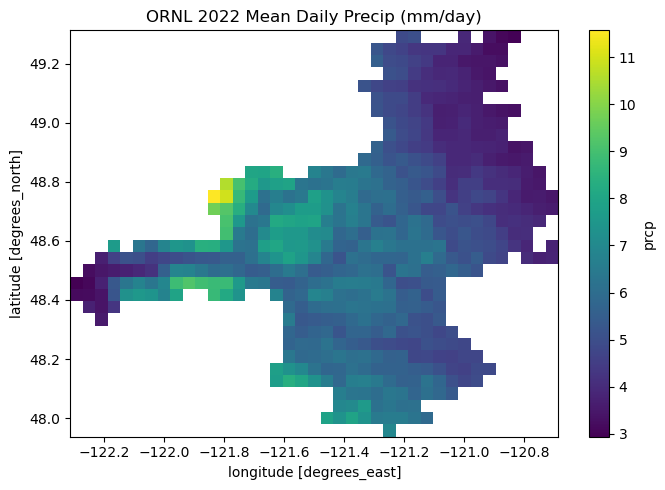

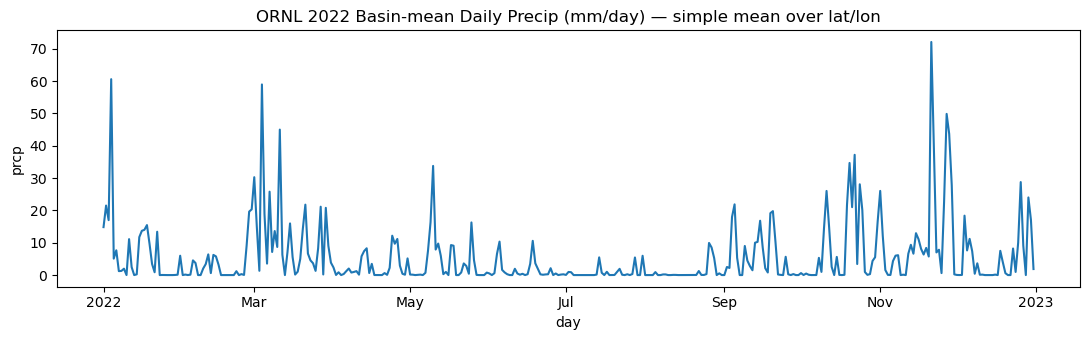

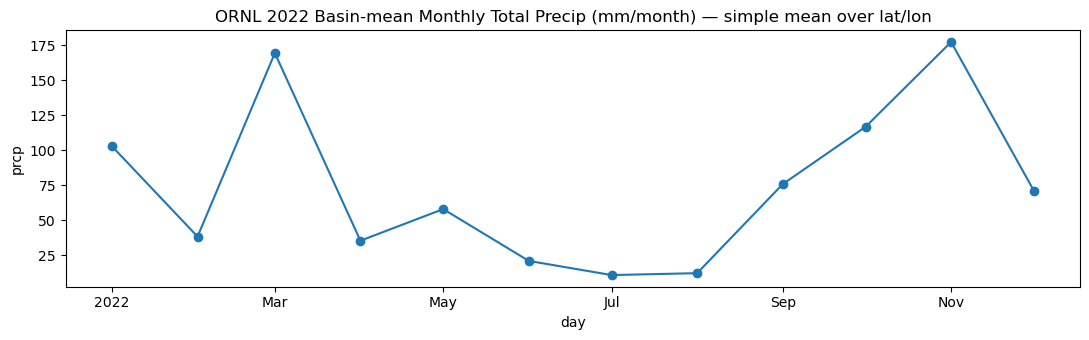

In [ ]:
# ORNL Zarr sanity-check + metadata consolidation + quick plots

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

ZARR_PATH = "/data0/balaji24/data/ornl/2022_2022_CNRM-ESM2-1_ssp585_DBCCA_ORNL_data.zarr"

# --- 0) Open (avoid the consolidated-metadata warning by being explicit) ---
ds = xr.open_zarr(ZARR_PATH, consolidated=False)  # explicit, so no warning
print("=== DATASET OVERVIEW ===")
print(ds)

# --- 1) Basic checks ---
print("\n=== TIME RANGE ===")
print("Start:", ds.time.min().values)
print("End  :", ds.time.max().values)
print("Total timesteps:", ds.sizes.get("time", "N/A"))

print("\n=== VARIABLES ===")
print(list(ds.data_vars))

# --- 2) Stats + NaN interpretation ---
if "prcp" not in ds:
    raise KeyError("Expected variable 'prcp' not found. Check your --parameters value.")

pr = ds["prcp"]

# Total cells and NaN counts
total_cells = int(np.prod([ds.sizes[d] for d in pr.dims]))
nan_cells = int(pr.isnull().sum().compute())
nan_frac = nan_cells / total_cells

print("\n=== PRCP STATS (entire year) ===")
print("Min :", float(pr.min().compute()))
print("Mean:", float(pr.mean().compute()))
print("Max :", float(pr.max().compute()))
print(f"NaNs: {nan_cells} / {total_cells} ({nan_frac:.1%})")
print("Note: Many NaNs are expected if the dataset is basin-clipped (outside-basin cells are NaN).")

# --- 3) January slice check ---
jan = ds.sel(time=slice("2022-01-01", "2022-01-31"))
print("\n=== JAN 2022 CHECK ===")
print("Jan time range:", jan.time.min().values, "→", jan.time.max().values)
print("Jan prcp mean:", float(jan.prcp.mean().compute()))

# --- 4) Quick visuals ---
# 4a) Mean precip map
plt.figure(figsize=(7, 5))
pr.mean("time").plot()
plt.title("ORNL 2022 Mean Daily Precip (mm/day)")
plt.tight_layout()
plt.show()

# 4b) Basin-mean daily time series (simple: mean over lat/lon ignoring NaNs)
# (This is not area-weighted; it’s still a good sanity check.)
basin_mean_ts = pr.mean(("lat", "lon"), skipna=True)

plt.figure(figsize=(11, 3.5))
basin_mean_ts.plot()
plt.title("ORNL 2022 Basin-mean Daily Precip (mm/day) — simple mean over lat/lon")
plt.tight_layout()
plt.show()

# 4c) Monthly totals (sum of daily mm/day to mm/month)
monthly_total = pr.resample(time="MS").sum(skipna=True).mean(("lat", "lon"), skipna=True)

plt.figure(figsize=(11, 3.5))
monthly_total.plot(marker="o")
plt.title("ORNL 2022 Basin-mean Monthly Total Precip (mm/month) — simple mean over lat/lon")
plt.tight_layout()
plt.show()

# --- 5) consolidate Zarr metadata for faster future opens ---
# This removes the "failed to open consolidated metadata" warning if you later use consolidated=True
DO_CONSOLIDATE = False  # set True if you want to consolidate metadata in-place

if DO_CONSOLIDATE:
    import zarr
    print("\nConsolidating Zarr metadata (in-place)...")
    zarr.consolidate_metadata(ZARR_PATH)
    print("Done. You can now open faster with: xr.open_zarr(ZARR_PATH, consolidated=True)")

In [1]:
import xarray as xr
import pandas as pd

z = "/data0/balaji24/data/weather_data/2024-01_HRRR_data.zarr"
ds = xr.open_zarr(z)

t = pd.to_datetime(ds.time.values)
print("Time range:", t.min(), "→", t.max())
print("Timesteps:", len(t))

# Expected hours in Jan 2024 = 31*24 = 744 (if hourly)
# If you store both f00 and f01 separately, count may differ,
# but timesteps should still be close to expected.
expected = 31 * 24
print("Expected (hourly):", expected, "Missing:", expected - len(t))

Time range: 2024-01-05 04:00:00 → 2024-01-26 15:00:00
Timesteps: 211
Expected (hourly): 744 Missing: 533


In [ ]:
from __future__ import annotations

import re
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
YEAR_MIN = 2014
YEAR_MAX = 2024

P_PRISM_DIR = Path("/data0/balaji24/data/prism_ppt")
P_HRRR_DIR  = Path("/data0/balaji24/data/weather_data")
P_WRF_DIR   = Path("/data0/balaji24/data/ucla_wrf_outputs")

CSV_OUT = Path("/data0/balaji24/data/annual_precip_skagit_2014_2024.csv")
PNG_OUT = Path("/data0/balaji24/data/annual_precip_skagit_2014_2024.png")


# -------------------- HELPERS --------------------
def safe_open_zarr(path: Path) -> xr.Dataset:
    return xr.open_zarr(path, consolidated=False)

def ensure_time_sorted_unique(da: xr.DataArray) -> xr.DataArray:
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    t = pd.to_datetime(da["time"].values)
    if len(t) == 0:
        return da
    # keep first occurrence of duplicate timestamps
    _, idx = np.unique(t.astype("datetime64[ns]"), return_index=True)
    idx = np.sort(idx)
    return da.isel(time=idx)

def looks_cumulative_1d(vals: np.ndarray) -> bool:
    # heuristic: mostly non-decreasing
    if vals.size < 10:
        return False
    dv = np.diff(vals[: min(vals.size, 200)])
    return (dv >= -1e-6).mean() > 0.90

def deaccumulate_generic(da: xr.DataArray, time_dim="time", clip_zero=True) -> xr.DataArray:
    """Convert cumulative precip to increments using diff; handle resets."""
    da = ensure_time_sorted_unique(da)
    dif = da.diff(time_dim)
    dif = dif.reindex({time_dim: da[time_dim]})
    dif = dif.fillna(0)
    if clip_zero:
        dif = dif.clip(min=0)
    return dif

def to_incremental_mm(da: xr.DataArray) -> xr.DataArray:
    """If cumulative, deaccumulate; else return as-is."""
    da = ensure_time_sorted_unique(da)

    # probe a single grid point series to test monotonicity
    probe = da
    for d in da.dims:
        if d != "time":
            probe = probe.isel({d: 0})
    vals = np.asarray(probe.values)

    if vals.ndim == 1 and looks_cumulative_1d(vals.astype("float64", copy=False)):
        return deaccumulate_generic(da, time_dim="time", clip_zero=True)
    return da

def basin_mean(da: xr.DataArray, spatial_dims: tuple[str, str]) -> xr.DataArray:
    """Mean over spatial dims; assumes outside-basin is NaN."""
    return da.mean(dim=spatial_dims, skipna=True)

def year_day_count(da: xr.DataArray, yr: int) -> int:
    if "time" not in da.dims or da["time"].size == 0:
        return 0
    sub = da.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    if sub["time"].size == 0:
        return 0
    return int(sub.resample(time="1D").sum()["time"].size)

def add_year_rows(rows, dataset_name: str, ann: xr.DataArray, yr: int, suffix: str = ""):
    if "year" not in ann.coords:
        return
    years = ann["year"].values
    if yr in years:
        val = float(ann.sel(year=yr).values)
        if np.isfinite(val):
            rows.append({"dataset": dataset_name + suffix, "year": int(yr), "mm": val})


# -------------------- MAIN --------------------
rows = []

# ---- PRISM ----
prism_zarrs = sorted(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr"))
if prism_zarrs:
    dsp = xr.concat([safe_open_zarr(p) for p in prism_zarrs],
                    dim="time", join="outer", coords="minimal", compat="override")
    if "ppt" in dsp:
        ppt = ensure_time_sorted_unique(dsp["ppt"])  # (time, lat, lon)
        bm = basin_mean(ppt, spatial_dims=("lat", "lon"))
        ann = bm.groupby("time.year").sum(skipna=True)

        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            days = year_day_count(bm, yr)
            suffix = " (partial)" if (yr == 2024 and days < 360 and days > 0) else ""
            add_year_rows(rows, "PRISM", ann, yr, suffix)

# ---- HRRR ----
hrrr_months = sorted([p for p in P_HRRR_DIR.glob("*_HRRR_data.zarr")
                      if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])

if hrrr_months:
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in hrrr_months if p.name.startswith(f"{yr}-")]
        if not parts:
            continue

        ds = xr.concat([safe_open_zarr(p) for p in parts],
                       dim="time", join="outer", coords="minimal", compat="override").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            continue

        da = ensure_time_sorted_unique(ds[var])       # (time, y, x)
        hourly_mm = to_incremental_mm(da)             # handle cumulative vs incremental
        daily_mm = hourly_mm.resample(time="1D").sum()
        bm = basin_mean(daily_mm, spatial_dims=("y", "x"))
        ann = bm.groupby("time.year").sum(skipna=True)

        days = year_day_count(bm, yr)
        suffix = " (partial)" if (days < 360 and days > 0) else ""
        add_year_rows(rows, "HRRR", ann, yr, suffix)

# ---- UCLA WRF ----
wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
by_year = {}

for z in wrf_zarrs:
    m = re.search(r"(\d{4})", z.name)
    if not m:
        continue
    yr = int(m.group(1))
    if YEAR_MIN <= yr <= YEAR_MAX:
        by_year.setdefault(yr, []).append(z)

for yr, parts in sorted(by_year.items()):
    dsw = xr.concat([safe_open_zarr(p) for p in sorted(parts)],
                    dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
    v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
    if not (v_nc or v_c):
        continue

    total_inc = None
    for vv in [v_nc, v_c]:
        if vv:
            inc = deaccumulate_generic(dsw[vv], time_dim="time", clip_zero=True)
            total_inc = inc if total_inc is None else (total_inc + inc)

    total_inc = ensure_time_sorted_unique(total_inc)
    daily = total_inc.resample(time="1D").sum()

    # pick spatial dims (WRF usually y/x or south_north/west_east)
    spatial_dims = None
    for cand in [("y", "x"), ("south_north", "west_east"), ("lat", "lon")]:
        if all(d in daily.dims for d in cand):
            spatial_dims = cand
            break
    if spatial_dims is None:
        spatial_dims = tuple([d for d in daily.dims if d != "time"])
        if len(spatial_dims) != 2:
            continue

    bm = basin_mean(daily, spatial_dims=spatial_dims)
    ann = bm.groupby("time.year").sum(skipna=True)

    days = year_day_count(bm, yr)
    suffix = " (partial)" if (days < 360 and days > 0) else ""
    add_year_rows(rows, "UCLA_WRF", ann, yr, suffix)


# -------------------- RESULTS --------------------
df = (pd.DataFrame(rows)
      .sort_values(["dataset", "year"])
      .reset_index(drop=True))

display(df)

CSV_OUT.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# Plot
plt.figure(figsize=(11, 6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)

plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title("Skagit Basin — Annual Precipitation (2014–2024)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)

plt.show()


,dataset,year,mm
0,HRRR,2015,429.982117
1,HRRR,2016,266.554535
2,HRRR,2017,43.765610
3,HRRR,2018,52.254791
4,HRRR,2019,39.422729
5,HRRR,2020,61.084167
6,HRRR,2021,55.329330
7,HRRR,2022,41.177521
8,HRRR,2023,38.195564
9,HRRR (partial),2014,54.824242


Saved CSV → /data0/balaji24/data/annual_precip_skagit_2014_2024.csv
Saved plot → /data0/balaji24/data/annual_precip_skagit_2014_2024.png


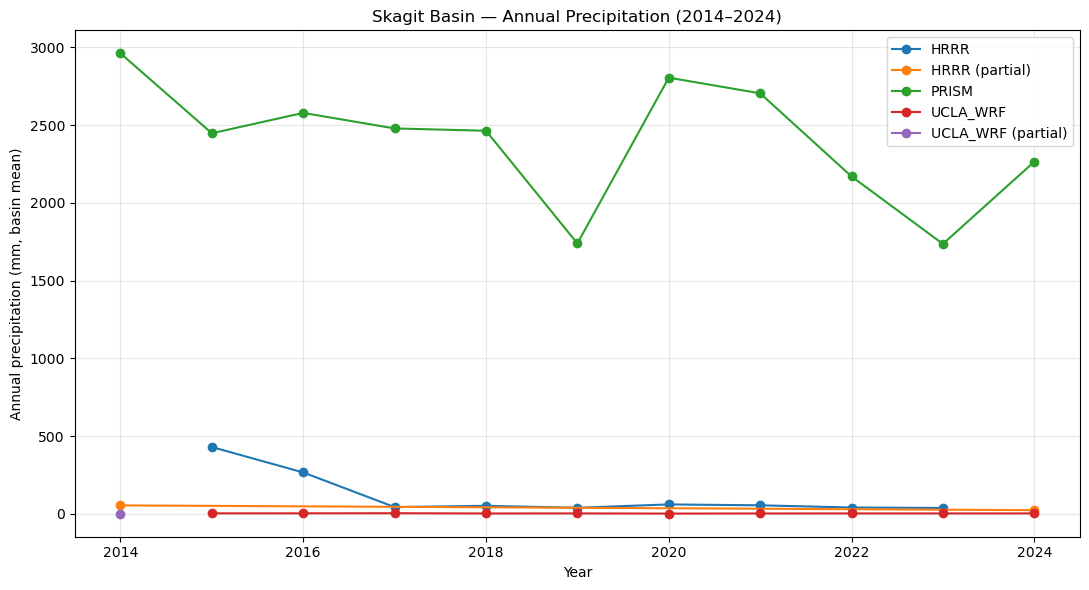

In [1]:
from __future__ import annotations

import re
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
YEAR_MIN = 2014
YEAR_MAX = 2024

P_PRISM_DIR = Path("/data0/balaji24/data/prism_ppt")
P_HRRR_DIR  = Path("/data0/balaji24/data/weather_data")
P_WRF_DIR   = Path("/data0/balaji24/data/ucla_wrf_outputs")

CSV_OUT = Path("/data0/balaji24/data/annual_precip_skagit_2014_2024.csv")
PNG_OUT = Path("/data0/balaji24/data/annual_precip_skagit_2014_2024.png")


# -------------------- HELPERS --------------------
def safe_open_zarr(path: Path) -> xr.Dataset:
    return xr.open_zarr(path, consolidated=False)

def ensure_time_sorted_unique(da: xr.DataArray) -> xr.DataArray:
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    t = pd.to_datetime(da["time"].values)
    if len(t) == 0:
        return da
    # keep first occurrence of duplicate timestamps
    _, idx = np.unique(t.astype("datetime64[ns]"), return_index=True)
    idx = np.sort(idx)
    return da.isel(time=idx)

def looks_cumulative_1d(vals: np.ndarray) -> bool:
    # heuristic: mostly non-decreasing
    if vals.size < 10:
        return False
    dv = np.diff(vals[: min(vals.size, 200)])
    return (dv >= -1e-6).mean() > 0.90

def deaccumulate_generic(da: xr.DataArray, time_dim="time", clip_zero=True) -> xr.DataArray:
    """Convert cumulative precip to increments using diff; handle resets."""
    da = ensure_time_sorted_unique(da)
    dif = da.diff(time_dim)
    dif = dif.reindex({time_dim: da[time_dim]})
    dif = dif.fillna(0)
    if clip_zero:
        dif = dif.clip(min=0)
    return dif

def to_incremental_mm(da: xr.DataArray) -> xr.DataArray:
    """If cumulative, deaccumulate; else return as-is."""
    da = ensure_time_sorted_unique(da)

    # probe a single grid point series to test monotonicity
    probe = da
    for d in da.dims:
        if d != "time":
            probe = probe.isel({d: 0})
    vals = np.asarray(probe.values)

    if vals.ndim == 1 and looks_cumulative_1d(vals.astype("float64", copy=False)):
        return deaccumulate_generic(da, time_dim="time", clip_zero=True)
    return da

def basin_mean(da: xr.DataArray, spatial_dims: tuple[str, str]) -> xr.DataArray:
    """Mean over spatial dims; assumes outside-basin is NaN."""
    return da.mean(dim=spatial_dims, skipna=True)

def year_day_count(da: xr.DataArray, yr: int) -> int:
    if "time" not in da.dims or da["time"].size == 0:
        return 0
    sub = da.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    if sub["time"].size == 0:
        return 0
    return int(sub.resample(time="1D").sum()["time"].size)

def add_year_rows(rows, dataset_name: str, ann: xr.DataArray, yr: int, suffix: str = ""):
    if "year" not in ann.coords:
        return
    years = ann["year"].values
    if yr in years:
        val = float(ann.sel(year=yr).values)
        if np.isfinite(val):
            rows.append({"dataset": dataset_name + suffix, "year": int(yr), "mm": val})


# -------------------- MAIN --------------------
rows = []

# ---- PRISM ----
prism_zarrs = sorted(P_PRISM_DIR.glob("*_daily_4km_PRISM_data.zarr"))
if prism_zarrs:
    dsp = xr.concat([safe_open_zarr(p) for p in prism_zarrs],
                    dim="time", join="outer", coords="minimal", compat="override")
    if "ppt" in dsp:
        ppt = ensure_time_sorted_unique(dsp["ppt"])  # (time, lat, lon)
        bm = basin_mean(ppt, spatial_dims=("lat", "lon"))
        ann = bm.groupby("time.year").sum(skipna=True)

        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            days = year_day_count(bm, yr)
            suffix = " (partial)" if (yr == 2024 and days < 360 and days > 0) else ""
            add_year_rows(rows, "PRISM", ann, yr, suffix)

# ---- HRRR ----
hrrr_months = sorted([p for p in P_HRRR_DIR.glob("*_HRRR_data.zarr")
                      if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)])

if hrrr_months:
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in hrrr_months if p.name.startswith(f"{yr}-")]
        if not parts:
            continue

        ds = xr.concat([safe_open_zarr(p) for p in parts],
                       dim="time", join="outer", coords="minimal", compat="override").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            continue

        da = ensure_time_sorted_unique(ds[var])       # (time, y, x)
        hourly_mm = to_incremental_mm(da)             # handle cumulative vs incremental
        daily_mm = hourly_mm.resample(time="1D").sum()
        bm = basin_mean(daily_mm, spatial_dims=("y", "x"))
        ann = bm.groupby("time.year").sum(skipna=True)

        days = year_day_count(bm, yr)
        suffix = " (partial)" if (days < 360 and days > 0) else ""
        add_year_rows(rows, "HRRR", ann, yr, suffix)

# ---- UCLA WRF ----
wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
by_year = {}

for z in wrf_zarrs:
    m = re.search(r"(\d{4})", z.name)
    if not m:
        continue
    yr = int(m.group(1))
    if YEAR_MIN <= yr <= YEAR_MAX:
        by_year.setdefault(yr, []).append(z)

for yr, parts in sorted(by_year.items()):
    dsw = xr.concat([safe_open_zarr(p) for p in sorted(parts)],
                    dim="time", join="outer", coords="minimal", compat="override").sortby("time")

    v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
    v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
    if not (v_nc or v_c):
        continue

    total_inc = None
    for vv in [v_nc, v_c]:
        if vv:
            inc = deaccumulate_generic(dsw[vv], time_dim="time", clip_zero=True)
            total_inc = inc if total_inc is None else (total_inc + inc)

    total_inc = ensure_time_sorted_unique(total_inc)
    daily = total_inc.resample(time="1D").sum()

    # pick spatial dims (WRF usually y/x or south_north/west_east)
    spatial_dims = None
    for cand in [("y", "x"), ("south_north", "west_east"), ("lat", "lon")]:
        if all(d in daily.dims for d in cand):
            spatial_dims = cand
            break
    if spatial_dims is None:
        spatial_dims = tuple([d for d in daily.dims if d != "time"])
        if len(spatial_dims) != 2:
            continue

    bm = basin_mean(daily, spatial_dims=spatial_dims)
    ann = bm.groupby("time.year").sum(skipna=True)

    days = year_day_count(bm, yr)
    suffix = " (partial)" if (days < 360 and days > 0) else ""
    add_year_rows(rows, "UCLA_WRF", ann, yr, suffix)


# -------------------- RESULTS --------------------
df = (pd.DataFrame(rows)
      .sort_values(["dataset", "year"])
      .reset_index(drop=True))

display(df)

CSV_OUT.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# Plot
plt.figure(figsize=(11, 6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)

plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title("Skagit Basin — Annual Precipitation (2014–2024)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)

plt.show()


[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)

=== SNOTEL mean annual precipitation (mm) ===
2014: 2749.9 mm
2015: 2219.5 mm
2016: 2300.7 mm
2017: 2158.4 mm
2018: 1905.3 mm
2019: 1368.8 mm
2020: 2114.5 mm
2021: 2241.5 mm
2022: 1854.7 mm
2023: 1479.5 mm
2024: 1903.5 mm

PNNL mask array shape: (450, 450)   Basin cells: 228

[PNNL] Year 2014 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5454.7705078125
  [PNNL] Skagit basin annual precip 2014: 2366.1 mm

[PNNL] Year 2015 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5943.8974609375
  [PNNL] Skagit basin annual precip 2015: 2188.5 mm

[PNNL] Year 2016 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y')

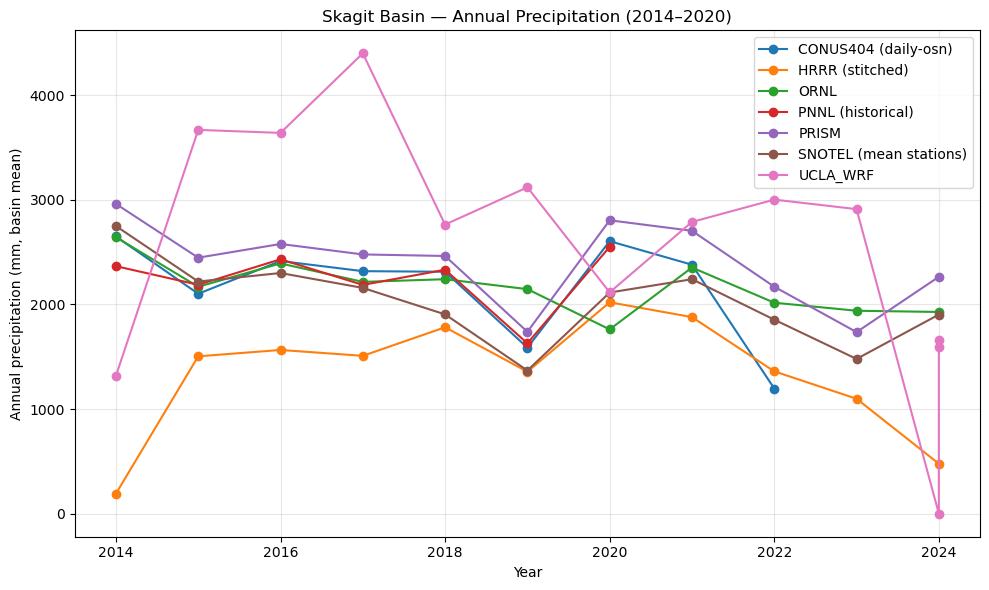

In [ ]:
# ============================
# Skagit Basin — Annual Precip (mm) by dataset (2014–2020)
# Safe, de-accumulating where needed, robust to duplicates
# ============================
import json, re, os
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO  = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # expect many *_HRRR_data.zarr months
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # annual zarrs
P_SNOTEL_DIR = BASE / "snotel"                   # monthly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year
PNNL_GEO     = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

# our derived CONUS404 Zarr (from your previous step)
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.csv"
PNG_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

# Load polygon
def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

# Build a regionmask mask on a dataset that has 2D lon/lat
def skagit_mask(ds_with_latlon):
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        # Drop a time dim if present (take first slice; grid is static)
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        # Squeeze any length-1 dims
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        # If still >2D (rare), try to pick the first index along extra dims
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    # Load basin polygon
    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    # regionmask wants (lon, lat) in 1D/2D
    m = regions.mask(lon, lat)   # NaN outside, 0 inside
    return m.isnull() == False   # True inside

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        # drop duplicate time stamps if any (avoid Pandas dtype casts on dask)
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """
    Normalize precip to *incremental per step* in mm.
    - Converts units if possible.
    - If cumulative/resetting, de-accumulate with clipping.
    """
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    # convert meters to mm
    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    # kg m^-2 ≈ mm
    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    # decide cumulative
    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc","rainnc","rainc","acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        # prepend 0 at first timestep
        inc = xr.concat([da.isel(time=slice(0,1))*0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    # treat as already per-step (e.g., mm/hour or mm/day in input)
    return da

def basin_mean(da, grid_ds=None):
    """
    Basin-average on the field's native grid using a Skagit mask.
    If grid_ds is provided, use its lat/lon to build the mask.
    """
    time_dim = next((d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time")
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        # fallback plain mean if we cannot mask for some reason
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

def annual_sum_mm(da):
    """Sum to annual (mm). Uses xarray .dt.year to avoid pandas casting issues."""
    if "time" not in da.dims:
        out = xr.DataArray(da)
        out = out.rename("mm")
        return out
    years = da["time"].dt.year
    out = da.groupby(years).sum("time")
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    # If xarray keeps a coord name like 'time_year', normalize it:
    if "time.year" in out.coords:
        out = out.rename({"time.year": "year"})
    out.name = "mm"
    return out

def pick_year(ann, yr):
    try:
        # support either a 'year' coord or a bare coordinate
        if "year" in ann.coords:
            return float(ann.sel(year=yr).values)
        # fallback if the coord is named something else:
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: yr}).values)
        return float(ann.values.item())  # single value
    except Exception:
        return np.nan

# --------- Extra helpers for HRRR (from your robust block) ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    """
    Turn a cumulative series into per-step increments.
    Works with plain 'time' or per-run accumulations if 'run'/'step' exist.
    """
    run_coord = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Return hourly precipitation increments in mm from HRRR.
    Detects cumulative vs incremental and handles resets.
    """
    da = ds[var]
    # Heuristic: if monotonic along a short slice, treat as cumulative
    probe = da.isel({k:0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])  # mm/day
            bm = basin_mean(da, grid_ds=dso)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"ORNL", "year": yr, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])  # mm/day
            bm = basin_mean(da, grid_ds=dsp)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"PRISM", "year": yr, "mm": val})

# ---------- HRRR (stitched monthly zarrs; robust de-accumulation) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
if hrrr_months:
    # Keep only files like YYYY-MM_HRRR_data.zarr
    monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in monthly if p.name.startswith(f"{yr}-")]
        if not parts:
            continue
        dsets = [safe_open_zarr(p) for p in parts]
        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            # close any opened pieces before skipping
            for d in dsets:
                d.close()
            continue

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)   # increments in mm
        daily     = hourly_mm.resample(time="1D").sum()   # daily totals
        bm        = basin_mean(daily, grid_ds=ds)         # basin mean
        ann       = bm.groupby("time.year").sum(skipna=True)  # annual

        if "year" in ann.coords and (yr in ann["year"].values):
            rows.append({"dataset":"HRRR (stitched)", "year": yr, "mm": float(ann.sel(year=yr).values)})

        # close to free handles
        for d in dsets:
            d.close()

# ---------- UCLA WRF (yearly zarrs; RAINNC/RAINC cumulative mm with resets) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        yr = int(m.group(1)) if m else None
        if yr is None or not (YEAR_MIN <= yr <= YEAR_MAX):
            continue
        dsw = safe_open_zarr(z)
        v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            continue
        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)  # diff + clip
                total = inc if total is None else total + inc
        total = ensure_time_sorted_unique(total)
        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        ann = annual_sum_mm(bm)
        val = pick_year(ann, yr)
        if not np.isnan(val):
            rows.append({"dataset":"UCLA_WRF", "year": yr, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = (
        "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/"
        "all_stations.geojson"
    )

    # --- load GeoJSON WITHOUT gpd.read_file (avoids GDAL/Fiona segfaults) ---
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records = []
        geoms = []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))

        if not records:
            stations = None
        else:
            stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        # 2) Load Skagit basin polygon and select stations inside it
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        # restrict to the 6–7 stations you care about
        desired_names = {
            "Beaver Pass",
            "Brown Top",
            "Marten Ridge",
            "Rainy Pass",
            "Swamp Creek",
            "Thunder Basin",
        }
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[
                skagit_stations["name"].isin(desired_names)
            ]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            # 3) For each station, pull daily CSV from GitHub and compute annual totals
            yearly_values = {}  # year to list of station totals (mm)
            base_csv_url = (
                "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            )

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA column for {code} ({name}), skipping.")
                    continue

                # precip in mm (PRCPSA is meters)
                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN}-01-01": f"{YEAR_MAX}-12-31"]

                annual = precip_mm.resample("YS").sum()
                for ts, val in annual.items():
                    yr = ts.year
                    if YEAR_MIN <= yr <= YEAR_MAX:
                        yearly_values.setdefault(yr, []).append(float(val))

            if not yearly_values:
                print("[SNOTEL] No annual data computed, skipping.")
            else:
                print("\n=== SNOTEL mean annual precipitation (mm) ===")
                for yr in sorted(yearly_values.keys()):
                    vals = np.array(yearly_values[yr], dtype="float64")
                    mm_mean = float(np.nanmean(vals))
                    print(f"{yr}: {mm_mean:.1f} mm")
                    rows.append(
                        {"dataset": "SNOTEL (mean stations)", "year": yr, "mm": mm_mean}
                    )
                print("============================================\n")

# ---------- PNNL (historical; hourly PREC_ACC_NC - annual total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    # Load the validated Skagit mask as a plain NumPy boolean array
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)   # shape (450, 450)
    print("PNNL mask array shape:", Skmask.shape, "  Basin cells:", int(Skmask.sum()))

    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        files = sorted(glob(str(PNNL_HIST / f"{yr}" / "*PREC_ACC_NC*.nc")))
        if not files:
            print(f"[PNNL] Year {yr}: no PREC_ACC_NC files, skipping")
            continue

        print(f"\n[PNNL] Year {yr} → {len(files)} file(s)")
        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
        )

        # Find precip var (PREC_ACC_NC)
        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            print(f"  [PNNL] No PREC_ACC_NC var for {yr}, skipping")
            dsp.close()
            continue

        p = dsp[v]   # dims like ('time', 'x', 'y')  or ('time', 'y', 'x')
        print("  PNNL precip dims:", p.dims, "shape:", tuple(p.shape))

        # Sort & deduplicate time
        p = ensure_time_sorted_unique(p)

        # restrict strictly to that calendar year
        p = p.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))

        # === Annual sum over time - 2D field in model grid ===
        Pann = p.sum(dim="time").values          # NumPy array, shape (450, 450)
        print("  Annual field min/max:", float(Pann.min()), float(Pann.max()))

        # Sanity check: grid must match mask shape
        if Pann.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: Pann {Pann.shape} vs mask {Skmask.shape}")

        basin_mean_val = float(Pann[Skmask].mean())
        print(f"  [PNNL] Skagit basin annual precip {yr}: {basin_mean_val:.1f} mm")

        rows.append({
            "dataset": "PNNL (historical)",
            "year": yr,
            "mm": basin_mean_val,
        })

        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake, like notebook cell) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")

    # 1) Open CONUS404 daily dataset from HyTEST catalog
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    print("✓ Loaded conus404-daily-osn")

    # 2) Select precip + time range
    var = "PREC_ACC_NC"
    if var not in ds.data_vars:
        print(f"[CONUS404] {var} not found in dataset, skipping.")
    else:
        precip = ds[var].sel(time=slice(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))
        print("✓ Selected PREC_ACC_NC for study period")

        # 3) Load Skagit boundary and build mask
        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]
        print("✓ Loaded Skagit boundary")

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # shape (y, x)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))
        print("✓ Built Skagit mask")

        # 4) Basin-mean daily precip time series
        precip_skagit = precip.where(mask_da)
        skagit_daily = precip_skagit.mean(dim=("y", "x"))
        print("✓ Computed basin-mean daily precip")

        # 5) Annual totals (mm per year, basin mean)
        skagit_annual = skagit_daily.resample(time="YS").sum()
        years = skagit_annual["time"].dt.year.values
        values = skagit_annual.values

        # Add to rows for master DF
        for y, v in zip(years, values):
            y_int = int(y)
            if YEAR_MIN <= y_int <= YEAR_MAX:
                rows.append(
                    {"dataset": "CONUS404 (daily-osn)", "year": y_int, "mm": float(v)}
                )

        # Print precipitation values
        print("\n=== CONUS404 Annual Precipitation (mm) ===")
        for y, v in zip(years, values):
            print(f"{int(y)} : {float(v):.2f} mm")
        print("==========================================\n")

        print(f"✓ Added {len(years)} CONUS404 annual values")

# ---------------- Results ----------------
df = pd.DataFrame(rows).sort_values(["dataset","year"]).reset_index(drop=True)
print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# quick plot (optional)
plt.figure(figsize=(10,6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title("Skagit Basin — Annual Precipitation (2014–2020)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

In [1]:
import re
from pathlib import Path
import numpy as np
import xarray as xr

YEAR_MIN, YEAR_MAX = 2014, 2024
BASE = Path("/data0/balaji24/data")

# Paths (edit if yours differ)
P_HRRR_DIR = BASE / "weather_data"          # monthly *_HRRR_data.zarr
P_WRF_DIR  = BASE / "ucla_wrf_outputs"      # UCLA WRF zarrs
BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")

def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def year_coverage_from_times(times):
    """Return dict: year -> (min_time, max_time, n_unique_times, expected_days, actual_days)"""
    times = np.array(times)
    times = times[~np.isnat(times)]
    if len(times) == 0:
        return {}
    # unique + sort
    ut = np.unique(times)
    ut.sort()

    years = xr.DataArray(ut).dt.year.values
    out = {}
    for y in range(YEAR_MIN, YEAR_MAX + 1):
        mask = years == y
        if not mask.any():
            continue
        yt = ut[mask]
        # expected days in that year
        expected_days = 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365
        # count unique days actually present
        days = np.unique(xr.DataArray(yt).dt.floor("D").values)
        out[y] = {
            "min_time": str(yt.min()),
            "max_time": str(yt.max()),
            "n_unique_times": int(len(yt)),
            "n_unique_days": int(len(days)),
            "expected_days": int(expected_days),
            "day_coverage_frac": float(len(days) / expected_days),
        }
    return out

def print_cov(title, cov):
    print(f"\n===== {title} coverage =====")
    if not cov:
        print("No times found.")
        return
    for y in sorted(cov):
        c = cov[y]
        flag = "✅" if c["day_coverage_frac"] > 0.98 else "⚠️"
        print(
            f"{flag} {y}: days {c['n_unique_days']}/{c['expected_days']} "
            f"({c['day_coverage_frac']*100:.1f}%) | "
            f"time range {c['min_time']} → {c['max_time']} | "
            f"unique times={c['n_unique_times']}"
        )

# -----------------------
# 1) HRRR monthly Zarrs
# -----------------------
hrrr_months = sorted(P_HRRR_DIR.glob("2024-??_HRRR_data.zarr"))
print("HRRR monthly zarrs found:", [p.name for p in hrrr_months])

if hrrr_months:
    # concatenate just times (cheap)
    all_times = []
    for p in hrrr_months:
        ds = safe_open_zarr(p)
        if "time" in ds:
            all_times.append(ds["time"].values)
        ds.close()
    if all_times:
        all_times = np.concatenate(all_times)
    cov_hrrr = year_coverage_from_times(all_times)
    print_cov("HRRR", cov_hrrr)

    # Also check duplicates in HRRR times (this is what caused your July crash)
    ut, counts = np.unique(all_times, return_counts=True)
    dup = ut[counts > 1]
    print("\nHRRR duplicate timestamps count:", len(dup))
    if len(dup) > 0:
        print("First 10 duplicates:", dup[:10])

# -----------------------
# 2) UCLA WRF Zarrs
# -----------------------
wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
# keep only 2024-ish or within year range
wrf_zarrs = [p for p in wrf_zarrs if re.search(r"\b(20\d{2})\b", p.name)]
print("\nUCLA WRF zarrs found:", len(wrf_zarrs))

# collect times across all zarrs
all_times = []
for p in wrf_zarrs:
    ds = safe_open_zarr(p)
    if "time" in ds:
        all_times.append(ds["time"].values)
    ds.close()

if all_times:
    all_times = np.concatenate(all_times)
cov_wrf = year_coverage_from_times(all_times)
print_cov("UCLA WRF", cov_wrf)

# -----------------------
# 3) CONUS404 availability check (quick)
# -----------------------
try:
    import intake, geopandas as gpd, shapely
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    conus = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    tmin = str(conus.time.min().compute().values)
    tmax = str(conus.time.max().compute().values)
    ymax = int(conus.time.dt.year.max().compute().values)
    print("\n===== CONUS404 (daily-osn) availability =====")
    print("time range:", tmin, "→", tmax)
    print("max year in source:", ymax)
except Exception as e:
    print("\n[CONUS404] Could not load intake source here:", repr(e))


HRRR monthly zarrs found: ['2024-01_HRRR_data.zarr', '2024-02_HRRR_data.zarr', '2024-03_HRRR_data.zarr', '2024-04_HRRR_data.zarr', '2024-05_HRRR_data.zarr', '2024-06_HRRR_data.zarr']

===== HRRR coverage =====
⚠️ 2024: days 152/366 (41.5%) | time range 2024-01-01T00:00:00.000000000 → 2024-06-30T00:00:00.000000000 | unique times=3510

HRRR duplicate timestamps count: 3510
First 10 duplicates: ['2024-01-01T00:00:00.000000000' '2024-02-01T00:00:00.000000000'
 '2024-02-01T01:00:00.000000000' '2024-02-01T02:00:00.000000000'
 '2024-02-01T03:00:00.000000000' '2024-02-01T04:00:00.000000000'
 '2024-02-01T05:00:00.000000000' '2024-02-01T06:00:00.000000000'
 '2024-02-01T07:00:00.000000000' '2024-02-01T08:00:00.000000000']

UCLA WRF zarrs found: 13

===== UCLA WRF coverage =====
⚠️ 2014: days 122/365 (33.4%) | time range 2014-09-01T00:00:00.000000000 → 2014-12-31T00:00:00.000000000 | unique times=2905
✅ 2015: days 365/365 (100.0%) | time range 2015-01-01T00:00:00.000000000 → 2015-12-31T00:00:00.00

In [6]:
import numpy as np
import pandas as pd
import xarray as xr

def basin_mean(da, grid_ds=None):
    """
    Compute basin mean precipitation.
    Assumes da already masked to basin OR full grid mean is acceptable.
    """
    # If grid_ds has a basin mask, use it (optional)
    if grid_ds is not None:
        for name in ["mask", "basin_mask"]:
            if name in grid_ds:
                da = da.where(grid_ds[name])

    spatial_dims = [d for d in da.dims if d != "time"]
    return da.mean(dim=spatial_dims, skipna=True)

def annual_sum_mm(da):
    """
    Convert daily (or sub-daily) precipitation to annual totals.
    """
    if "time" not in da.dims:
        return da

    return da.resample(time="1Y").sum()

def pick_year(da, year):
    """
    Extract the annual value for a specific year.
    Returns float or np.nan.
    """
    if da is None or "time" not in da.dims:
        return np.nan

    years = pd.to_datetime(da.time.values).year
    if year not in years:
        return np.nan

    return float(da.sel(time=str(year)).values.squeeze())


In [7]:
import re
import numpy as np

wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))

records = []

for z in wrf_zarrs:
    m = re.search(r"(\d{4})", z.name)
    yr = int(m.group(1)) if m else None
    if yr != 2024:
        continue

    print("\n---")
    print("File:", z.name)

    dsw = safe_open_zarr(z)

    v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
    v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)

    total = None
    for vv in [v_nc, v_c]:
        if vv:
            inc = to_incremental_mm(dsw[vv], force_cumulative=True)
            total = inc if total is None else total + inc

    total = ensure_time_sorted_unique(total)
    daily = total.resample(time="1D").sum()
    bm = basin_mean(daily, grid_ds=dsw)
    ann = annual_sum_mm(bm)

    val = pick_year(ann, 2024)
    print("2024 contribution (mm):", val)

    records.append({
        "file": z.name,
        "mm": val
    })

print("\n=== UCLA 2024 breakdown ===")
for r in records:
    print(r)

print("\nFINAL UCLA 2024 TOTAL (sum of all parts):",
      np.nansum([r["mm"] for r in records]))


---
File: 2024-01-01_2024-01-01_wrf_cesm2_r11i1p1f1_ssp245_data.zarr


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


2024 contribution (mm): 0.0

---
File: 2024-01-01_2024-08-31_wrf_cesm2_r11i1p1f1_ssp245_data.zarr


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


2024 contribution (mm): 1.7170114517211914

---
File: 2024-09-01_2024-12-31_wrf_cesm2_r11i1p1f1_ssp245_data.zarr


/home/balaji24/skagit-met/.pixi/envs/analysis/lib/python3.11/site-packages/xarray/groupers.py:498: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


2024 contribution (mm): 1.6473851203918457

=== UCLA 2024 breakdown ===
{'file': '2024-01-01_2024-01-01_wrf_cesm2_r11i1p1f1_ssp245_data.zarr', 'mm': 0.0}
{'file': '2024-01-01_2024-08-31_wrf_cesm2_r11i1p1f1_ssp245_data.zarr', 'mm': 1.7170114517211914}
{'file': '2024-09-01_2024-12-31_wrf_cesm2_r11i1p1f1_ssp245_data.zarr', 'mm': 1.6473851203918457}

FINAL UCLA 2024 TOTAL (sum of all parts): 3.364396572113037


In [8]:
z = P_WRF_DIR / "2024-01-01_2024-08-31_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
dsw = safe_open_zarr(z)

for v in ["RAINNC", "RAINC"]:
    if v in dsw:
        print(v, "units:", dsw[v].attrs.get("units"), "| min/max:", float(dsw[v].min()), float(dsw[v].max()))


RAINNC units: mm | min/max: 608.1717529296875 4981.4775390625
RAINC units: mm | min/max: 7.475876808166504 860.0230102539062


[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)

=== SNOTEL mean annual precipitation (mm) ===
2014: 2749.9 mm
2015: 2219.5 mm
2016: 2300.7 mm
2017: 2158.4 mm
2018: 1905.3 mm
2019: 1368.8 mm
2020: 2114.5 mm
2021: 2241.5 mm
2022: 1854.7 mm
2023: 1479.5 mm
2024: 1903.5 mm

PNNL mask array shape: (450, 450)   Basin cells: 228

[PNNL] Year 2014 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5454.7705078125
  [PNNL] Skagit basin annual precip 2014: 2366.1 mm

[PNNL] Year 2015 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y') shape: (8760, 450, 450)
  Annual field min/max: 0.0 5943.8974609375
  [PNNL] Skagit basin annual precip 2015: 2188.5 mm

[PNNL] Year 2016 → 1 file(s)
  PNNL precip dims: ('time', 'x', 'y')

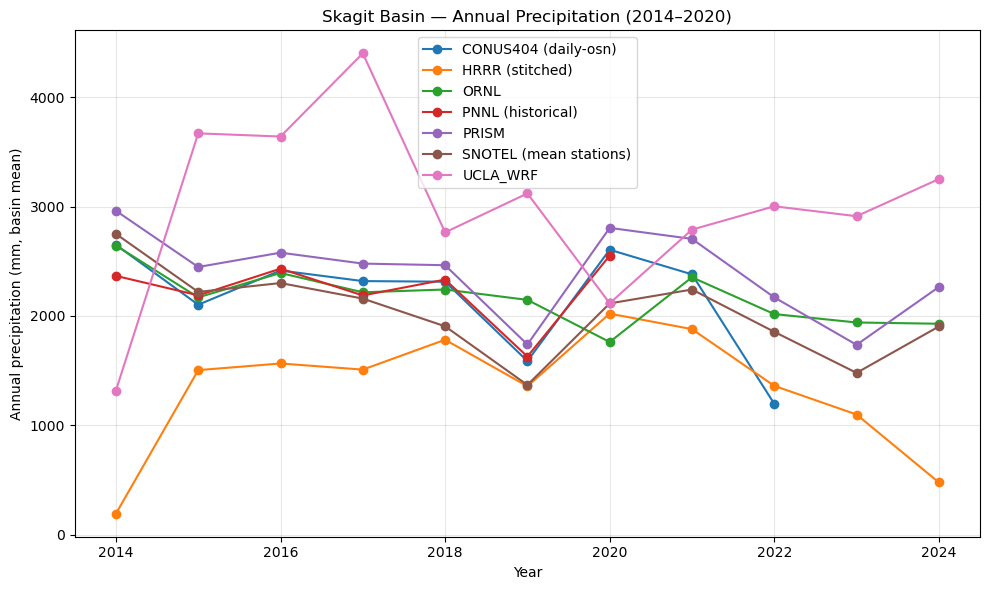

In [ ]:
# ============================
# Skagit Basin — Annual Precip (mm) by dataset (2014–2020)
# Safe, de-accumulating where needed, robust to duplicates
# ============================
import json, re, os
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO  = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # expect many *_HRRR_data.zarr months
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # annual zarrs
P_SNOTEL_DIR = BASE / "snotel"                   # monthly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year
PNNL_GEO     = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

# our derived CONUS404 Zarr (from your previous step)
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.csv"
PNG_OUT = OUT / "annual_precip_skagit_2014_2020_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

# Load polygon
def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

# Build a regionmask mask on a dataset that *has* 2D lon/lat
def skagit_mask(ds_with_latlon):
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        # Drop a time dim if present (take first slice; grid is static)
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        # Squeeze any length-1 dims
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        # If still >2D (rare), try to pick the first index along extra dims
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    # Load basin polygon
    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    # regionmask wants (lon, lat) in 1D/2D
    m = regions.mask(lon, lat)   # NaN outside, 0 inside
    return m.isnull() == False   # True inside

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        # drop duplicate time stamps if any (avoid Pandas dtype casts on dask)
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """
    Normalize precip to *incremental per step* in mm.
    - Converts units if possible.
    - If cumulative/resetting, de-accumulate with clipping.
    """
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    # convert meters to mm
    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    # kg m^-2 ≈ mm
    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    # decide cumulative
    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc","rainnc","rainc","acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        # prepend 0 at first timestep
        inc = xr.concat([da.isel(time=slice(0,1))*0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    # treat as already per-step (e.g., mm/hour or mm/day in input)
    return da

def basin_mean(da, grid_ds=None):
    """
    Basin-average on the field's native grid using a Skagit mask.
    If grid_ds is provided, use its lat/lon to build the mask.
    """
    time_dim = next((d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time")
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        # fallback plain mean if we cannot mask for some reason
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

def annual_sum_mm(da):
    """Sum to annual (mm). Uses xarray .dt.year to avoid pandas casting issues."""
    if "time" not in da.dims:
        out = xr.DataArray(da)
        out = out.rename("mm")
        return out
    years = da["time"].dt.year
    out = da.groupby(years).sum("time")
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    # If xarray keeps a coord name like 'time_year', normalize it:
    if "time.year" in out.coords:
        out = out.rename({"time.year": "year"})
    out.name = "mm"
    return out

def pick_year(ann, yr):
    try:
        # support either a 'year' coord or a bare coordinate
        if "year" in ann.coords:
            return float(ann.sel(year=yr).values)
        # fallback if the coord is named something else:
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: yr}).values)
        return float(ann.values.item())  # single value
    except Exception:
        return np.nan

# --------- Extra helpers for HRRR (from your robust block) ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    """
    Turn a cumulative series into per-step increments.
    Works with plain 'time' or per-run accumulations if 'run'/'step' exist.
    """
    run_coord = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Return hourly precipitation increments in mm from HRRR.
    Detects cumulative vs incremental and handles resets.
    """
    da = ds[var]
    # Heuristic: if monotonic along a short slice, treat as cumulative
    probe = da.isel({k:0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])  # mm/day
            bm = basin_mean(da, grid_ds=dso)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"ORNL", "year": yr, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])  # mm/day
            bm = basin_mean(da, grid_ds=dsp)
            ann = annual_sum_mm(bm)
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset":"PRISM", "year": yr, "mm": val})

# ---------- HRRR (stitched monthly zarrs; robust de-accumulation) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
if hrrr_months:
    # Keep only files like YYYY-MM_HRRR_data.zarr
    monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in monthly if p.name.startswith(f"{yr}-")]
        if not parts:
            continue
        dsets = [safe_open_zarr(p) for p in parts]
        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            # close any opened pieces before skipping
            for d in dsets:
                d.close()
            continue

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)   # increments in mm
        daily     = hourly_mm.resample(time="1D").sum()   # daily totals
        bm        = basin_mean(daily, grid_ds=ds)         # basin mean
        ann       = bm.groupby("time.year").sum(skipna=True)  # annual

        if "year" in ann.coords and (yr in ann["year"].values):
            rows.append({"dataset":"HRRR (stitched)", "year": yr, "mm": float(ann.sel(year=yr).values)})

        # close to free handles
        for d in dsets:
            d.close()

# ---------- UCLA WRF (yearly zarrs; RAINNC/RAINC cumulative mm with resets) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        yr = int(m.group(1)) if m else None
        if yr is None or not (YEAR_MIN <= yr <= YEAR_MAX):
            continue
        dsw = safe_open_zarr(z)
        v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            continue
        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)  # diff + clip
                total = inc if total is None else total + inc
        total = ensure_time_sorted_unique(total)
        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        ann = annual_sum_mm(bm)
        val = pick_year(ann, yr)
        if not np.isnan(val):
            rows.append({"dataset":"UCLA_WRF", "year": yr, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = (
        "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/"
        "all_stations.geojson"
    )

    # --- load GeoJSON WITHOUT gpd.read_file (avoids GDAL/Fiona segfaults) ---
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records = []
        geoms = []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))

        if not records:
            stations = None
        else:
            stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        # 2) Load Skagit basin polygon and select stations inside it
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        # restrict to the 6–7 stations you care about
        desired_names = {
            "Beaver Pass",
            "Brown Top",
            "Marten Ridge",
            "Rainy Pass",
            "Swamp Creek",
            "Thunder Basin",
        }
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[
                skagit_stations["name"].isin(desired_names)
            ]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            # 3) For each station, pull daily CSV from GitHub and compute annual totals
            yearly_values = {}  # year - list of station totals (mm)
            base_csv_url = (
                "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            )

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA column for {code} ({name}), skipping.")
                    continue

                # precip in mm (PRCPSA is meters)
                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN}-01-01": f"{YEAR_MAX}-12-31"]

                annual = precip_mm.resample("YS").sum()
                for ts, val in annual.items():
                    yr = ts.year
                    if YEAR_MIN <= yr <= YEAR_MAX:
                        yearly_values.setdefault(yr, []).append(float(val))

            if not yearly_values:
                print("[SNOTEL] No annual data computed, skipping.")
            else:
                print("\n=== SNOTEL mean annual precipitation (mm) ===")
                for yr in sorted(yearly_values.keys()):
                    vals = np.array(yearly_values[yr], dtype="float64")
                    mm_mean = float(np.nanmean(vals))
                    print(f"{yr}: {mm_mean:.1f} mm")
                    rows.append(
                        {"dataset": "SNOTEL (mean stations)", "year": yr, "mm": mm_mean}
                    )
                print("============================================\n")

# ---------- PNNL (historical; hourly PREC_ACC_NC - annual total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    # Load the validated Skagit mask as a plain NumPy boolean array
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)   # shape (450, 450)
    print("PNNL mask array shape:", Skmask.shape, "  Basin cells:", int(Skmask.sum()))

    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        files = sorted(glob(str(PNNL_HIST / f"{yr}" / "*PREC_ACC_NC*.nc")))
        if not files:
            print(f"[PNNL] Year {yr}: no PREC_ACC_NC files, skipping")
            continue

        print(f"\n[PNNL] Year {yr} → {len(files)} file(s)")
        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
        )

        # Find precip var (PREC_ACC_NC)
        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            print(f"  [PNNL] No PREC_ACC_NC var for {yr}, skipping")
            dsp.close()
            continue

        p = dsp[v]   # dims like ('time', 'x', 'y')  or ('time', 'y', 'x')
        print("  PNNL precip dims:", p.dims, "shape:", tuple(p.shape))

        # Sort & deduplicate time
        p = ensure_time_sorted_unique(p)

        # (Optional) restrict strictly to that calendar year
        p = p.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))

        # === Annual sum over time - 2D field in model grid ===
        Pann = p.sum(dim="time").values          # NumPy array, shape (450, 450)
        print("  Annual field min/max:", float(Pann.min()), float(Pann.max()))

        # Sanity check: grid must match mask shape
        if Pann.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: Pann {Pann.shape} vs mask {Skmask.shape}")

        basin_mean_val = float(Pann[Skmask].mean())
        print(f"  [PNNL] Skagit basin annual precip {yr}: {basin_mean_val:.1f} mm")

        rows.append({
            "dataset": "PNNL (historical)",
            "year": yr,
            "mm": basin_mean_val,
        })

        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake, like notebook cell) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")

    # 1) Open CONUS404 daily dataset from HyTEST catalog
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    print("✓ Loaded conus404-daily-osn")

    # 2) Select precip + time range
    var = "PREC_ACC_NC"
    if var not in ds.data_vars:
        print(f"[CONUS404] {var} not found in dataset, skipping.")
    else:
        precip = ds[var].sel(time=slice(f"{YEAR_MIN}-01-01", f"{YEAR_MAX}-12-31"))
        print("✓ Selected PREC_ACC_NC for study period")

        # 3) Load Skagit boundary and build mask
        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]
        print("✓ Loaded Skagit boundary")

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)  # shape (y, x)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))
        print("✓ Built Skagit mask")

        # 4) Basin-mean daily precip time series
        precip_skagit = precip.where(mask_da)
        skagit_daily = precip_skagit.mean(dim=("y", "x"))
        print("✓ Computed basin-mean daily precip")

        # 5) Annual totals (mm per year, basin mean)
        skagit_annual = skagit_daily.resample(time="YS").sum()
        years = skagit_annual["time"].dt.year.values
        values = skagit_annual.values

        # Add to rows for master DF
        for y, v in zip(years, values):
            y_int = int(y)
            if YEAR_MIN <= y_int <= YEAR_MAX:
                rows.append(
                    {"dataset": "CONUS404 (daily-osn)", "year": y_int, "mm": float(v)}
                )

        # Print precipitation values
        print("\n=== CONUS404 Annual Precipitation (mm) ===")
        for y, v in zip(years, values):
            print(f"{int(y)} : {float(v):.2f} mm")
        print("==========================================\n")

        print(f"✓ Added {len(years)} CONUS404 annual values")

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "year"], as_index=False)
      .agg(mm=("mm", "sum"))   # 👈 THIS is the fix
      .sort_values(["dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# quick plot (optional)
plt.figure(figsize=(10,6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Year")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title("Skagit Basin — Annual Precipitation (2014–2020)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)

=== SNOTEL mean WATER YEAR precipitation (mm) ===
WY2014: 2133.8 mm
WY2015: 2205.8 mm
WY2016: 2390.7 mm
WY2017: 2172.3 mm
WY2018: 2162.7 mm
WY2019: 1566.1 mm
WY2020: 1848.2 mm
WY2021: 1990.0 mm
WY2022: 2276.6 mm
WY2023: 1491.0 mm
WY2024: 1787.8 mm

PNNL mask array shape: (450, 450)   Basin cells: 228

[PNNL] WY 2014 → 2 file(s)
  [PNNL] Skagit basin WY precip 2014: 1968.8 mm

[PNNL] WY 2015 → 2 file(s)
  [PNNL] Skagit basin WY precip 2015: 1958.9 mm

[PNNL] WY 2016 → 2 file(s)
  [PNNL] Skagit basin WY precip 2016: 2417.0 mm

[PNNL] WY 2017 → 2 file(s)
  [PNNL] Skagit basin WY precip 2017: 2408.7 mm

[PNNL] WY 2018 → 2 file(s)
  [PNNL] Skagit basin WY precip 2018: 2223.1 mm

[PNNL] WY 2019 → 2 file(s)
  [PNNL] Ska

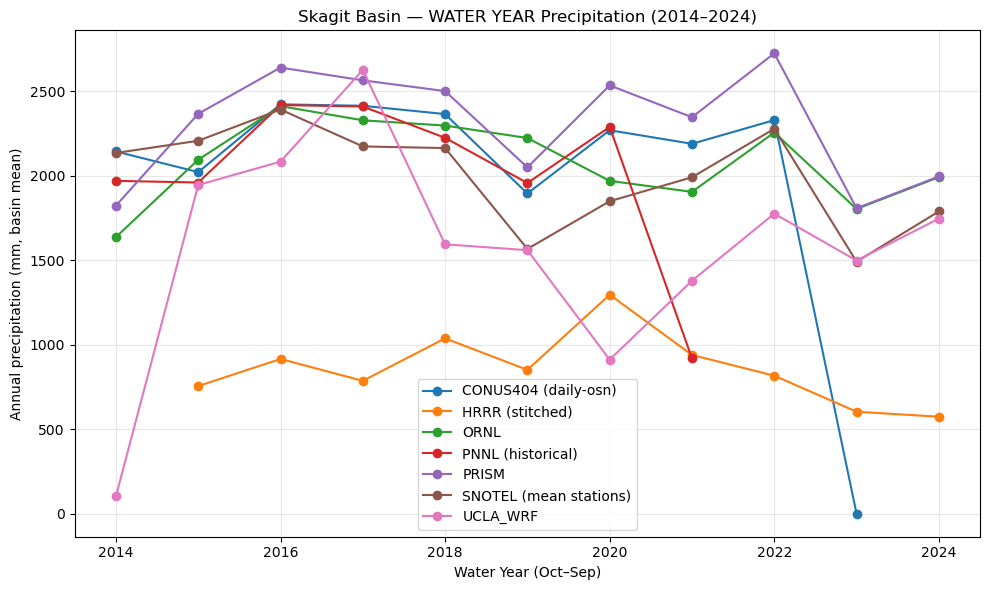

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (2014–2024)
# Safe, de-accumulating where needed, robust to duplicates
# ============================
import json, re, os
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO  = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024   # now interpreted as WATER YEAR labels (Oct–Sep)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # expect many *_HRRR_data.zarr months
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # annual zarrs
P_SNOTEL_DIR = BASE / "snotel"                   # monthly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year
PNNL_GEO     = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

# our derived CONUS404 Zarr (from your previous step)
P_CONUS_DERIVED = BASE / "derived" / "conus404_skagit_precip_daily.zarr"

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

# Load polygon
def _load_boundary_geom():
    from shapely.geometry import shape, Polygon, LinearRing
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if isinstance(obj, dict) and "type" in obj:
        if obj["type"] == "FeatureCollection":
            return shape(obj["features"][0]["geometry"])
        elif obj["type"] == "Feature":
            return shape(obj["geometry"])
        else:
            return shape(obj)
    elif isinstance(obj, dict) and {"lon","lat"} <= obj.keys():
        pts = list(zip(obj["lon"], obj["lat"]))
        if pts[0] != pts[-1]:
            pts.append(pts[0])
        return Polygon(LinearRing(pts))
    raise ValueError("Unrecognized boundary format")

# Build a regionmask mask on a dataset that *has* 2D lon/lat
def skagit_mask(ds_with_latlon):
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        # Drop a time dim if present (take first slice; grid is static)
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        # Squeeze any length-1 dims
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        # If still >2D (rare), try to pick the first index along extra dims
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    # Load basin polygon
    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name":["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    # regionmask wants (lon, lat) in 1D/2D
    m = regions.mask(lon, lat)   # NaN outside, 0 inside
    return m.isnull() == False   # True inside

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        # drop duplicate time stamps if any (avoid Pandas dtype casts on dask)
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """
    Normalize precip to *incremental per step* in mm.
    - Converts units if possible.
    - If cumulative/resetting, de-accumulate with clipping.
    """
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    # convert meters to mm
    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    # kg m^-2 ≈ mm
    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    # decide cumulative
    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc","rainnc","rainc","acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        # prepend 0 at first timestep
        inc = xr.concat([da.isel(time=slice(0,1))*0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    # treat as already per-step (e.g., mm/hour or mm/day in input)
    return da

def basin_mean(da, grid_ds=None):
    """
    Basin-average on the field's native grid using a Skagit mask.
    If grid_ds is provided, use its lat/lon to build the mask.
    """
    time_dim = next((d for d in da.dims if np.issubdtype(da[d].dtype, np.datetime64)), "time")
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        # fallback plain mean if we cannot mask for some reason
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

# ============================
# WATER YEAR aggregation helpers
# Water Year: Oct 1 to Sep 30, labeled by ending year
# ============================
def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum to WATER YEAR totals (mm)."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    # normalize coord name if needed
    if "time" in out.coords and "year" not in out.coords:
        pass
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    """Pick a WATER YEAR value from an annual series."""
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- Extra helpers for HRRR ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    """
    Turn a cumulative series into per-step increments.
    Works with plain 'time' or per-run accumulations if 'run'/'step' exist.
    """
    run_coord = next((c for c in ("run","init","forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step","lead","forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    """
    Return hourly precipitation increments in mm from HRRR.
    Detects cumulative vs incremental and handles resets.
    """
    da = ds[var]
    probe = da.isel({k:0 for k in da.dims if k not in ("time","step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])  # mm/day
            bm = basin_mean(da, grid_ds=dso)
            ann = water_year_sum_mm(bm)   
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_wy(ann, yr)    
                if not np.isnan(val):
                    rows.append({"dataset":"ORNL", "year": yr, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt","precip","prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])  # mm/day
            bm = basin_mean(da, grid_ds=dsp)
            ann = water_year_sum_mm(bm)  
            for yr in range(YEAR_MIN, YEAR_MAX+1):
                val = pick_wy(ann, yr)    
                if not np.isnan(val):
                    rows.append({"dataset":"PRISM", "year": yr, "mm": val})

# ---------- HRRR (stitched monthly zarrs; robust de-accumulation) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
if hrrr_months:
    monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        parts = [p for p in monthly if p.name.startswith(f"{yr}-")]
        if not parts:
            continue
        dsets = [safe_open_zarr(p) for p in parts]

        # leaving your concat unchanged (only WY aggregation changes requested)
        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal").sortby("time")

        var = "tp" if "tp" in ds else ("apcp" if "apcp" in ds else None)
        if not var:
            for d in dsets:
                d.close()
            continue

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)   # increments in mm
        daily     = hourly_mm.resample(time="1D").sum()   # daily totals
        bm        = basin_mean(daily, grid_ds=ds)         # basin mean
        ann       = water_year_sum_mm(bm)                 
        val       = pick_wy(ann, yr)                      

        if not np.isnan(val):
            rows.append({"dataset":"HRRR (stitched)", "year": yr, "mm": float(val)})

        for d in dsets:
            d.close()

# ---------- UCLA WRF (yearly zarrs; RAINNC/RAINC cumulative mm with resets) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        yr = int(m.group(1)) if m else None
        if yr is None or not (YEAR_MIN <= yr <= YEAR_MAX):
            continue
        dsw = safe_open_zarr(z)
        v_nc = next((n for n in ["RAINNC","rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC","rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            continue
        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)  # diff + clip
                total = inc if total is None else total + inc
        total = ensure_time_sorted_unique(total)
        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        ann = water_year_sum_mm(bm)  
        val = pick_wy(ann, yr)       
        if not np.isnan(val):
            rows.append({"dataset":"UCLA_WRF", "year": yr, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = (
        "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/"
        "all_stations.geojson"
    )

    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records = []
        geoms = []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))

        if not records:
            stations = None
        else:
            stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {
            "Beaver Pass",
            "Brown Top",
            "Marten Ridge",
            "Rainy Pass",
            "Swamp Creek",
            "Thunder Basin",
        }
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[
                skagit_stations["name"].isin(desired_names)
            ]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            yearly_values = {}  # WATER YEAR - list of station totals (mm)
            base_csv_url = (
                "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            )

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA column for {code} ({name}), skipping.")
                    continue

                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN-1}-10-01": f"{YEAR_MAX}-09-30"]

                # compute water year labels for the datetime index
                wy_idx = np.where(precip_mm.index.month >= 10,
                                  precip_mm.index.year + 1,
                                  precip_mm.index.year)
                tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                annual = tmp.groupby("wy")["mm"].sum()

                for wy, val in annual.items():
                    wy = int(wy)
                    if YEAR_MIN <= wy <= YEAR_MAX:
                        yearly_values.setdefault(wy, []).append(float(val))

            if not yearly_values:
                print("[SNOTEL] No annual data computed, skipping.")
            else:
                print("\n=== SNOTEL mean WATER YEAR precipitation (mm) ===")
                for wy in sorted(yearly_values.keys()):
                    vals = np.array(yearly_values[wy], dtype="float64")
                    mm_mean = float(np.nanmean(vals))
                    print(f"WY{wy}: {mm_mean:.1f} mm")
                    rows.append({"dataset": "SNOTEL (mean stations)", "year": wy, "mm": mm_mean})
                print("===============================================\n")

# ---------- PNNL (historical; hourly PREC_ACC_NC - WATER YEAR total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)   # shape (450, 450)
    print("PNNL mask array shape:", Skmask.shape, "  Basin cells:", int(Skmask.sum()))

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        # water year spans Oct (wy-1) to Sep (wy) - need both years' files
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        if not files:
            print(f"[PNNL] WY {wy}: no PREC_ACC_NC files, skipping")
            continue

        print(f"\n[PNNL] WY {wy} → {len(files)} file(s)")
        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            print(f"  [PNNL] No PREC_ACC_NC var for WY {wy}, skipping")
            dsp.close()
            continue

        p = dsp[v]
        p = ensure_time_sorted_unique(p)

        # slice to water year window
        p = p.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))

        if p.sizes.get("time", 0) == 0:
            print(f"  [PNNL] WY {wy}: empty after slicing, skipping")
            dsp.close()
            continue

        Pwy = p.sum(dim="time").values
        if Pwy.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: Pwy {Pwy.shape} vs mask {Skmask.shape}")

        basin_mean_val = float(Pwy[Skmask].mean())
        print(f"  [PNNL] Skagit basin WY precip {wy}: {basin_mean_val:.1f} mm")

        rows.append({"dataset": "PNNL (historical)", "year": wy, "mm": basin_mean_val})
        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake, like notebook cell) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")

    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    print("✓ Loaded conus404-daily-osn")

    var = "PREC_ACC_NC"
    if var not in ds.data_vars:
        print(f"[CONUS404] {var} not found in dataset, skipping.")
    else:
        # slice to cover the needed WY range
        precip = ds[var].sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))
        print("✓ Selected PREC_ACC_NC for study period")

        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]
        print("✓ Loaded Skagit boundary")

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))
        print("✓ Built Skagit mask")

        precip_skagit = precip.where(mask_da)
        skagit_daily = precip_skagit.mean(dim=("y", "x"))
        print("✓ Computed basin-mean daily precip")

        # WATER YEAR totals
        skagit_wy = water_year_sum_mm(skagit_daily)
        for wy in range(YEAR_MIN, YEAR_MAX + 1):
            val = pick_wy(skagit_wy, wy)
            if not np.isnan(val):
                rows.append({"dataset": "CONUS404 (daily-osn)", "year": wy, "mm": float(val)})

        print("\n=== CONUS404 WATER YEAR Precipitation (mm) ===")
        for wy in range(YEAR_MIN, YEAR_MAX + 1):
            val = pick_wy(skagit_wy, wy)
            if not np.isnan(val):
                print(f"WY{wy} : {float(val):.2f} mm")
        print("==============================================\n")

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "year"], as_index=False)
      .agg(mm=("mm", "sum"))   # keeps UCLA multi-part fix
      .sort_values(["dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# quick plot (optional)
plt.figure(figsize=(10,6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Water Year (Oct–Sep)")
plt.ylabel("Annual precipitation (mm, basin mean)")
plt.title(f"Skagit Basin — WATER YEAR Precipitation ({YEAR_MIN}–{YEAR_MAX})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: 1664.5 mm
[HRRR] WY2017: 1438.8 mm
[HRRR] WY2018: 1760.5 mm
[HRRR] WY2019: 1595.7 mm
[HRRR] WY2020: 1801.8 mm
[HRRR] WY2021: 1664.8 mm
[HRRR] WY2022: 1756.4 mm
[HRRR] WY2023: 1147.9 mm
[HRRR] WY2024: 1069.1 mm
[UCLA_WRF] WY2014: missing 2013 or 2014 zarr -> skipping
[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)
[CONUS404] Loading from HyTEST (conus404-daily-osn)...
                 dataset  year           mm
0   CONUS404 (daily-osn)  2014  2142.

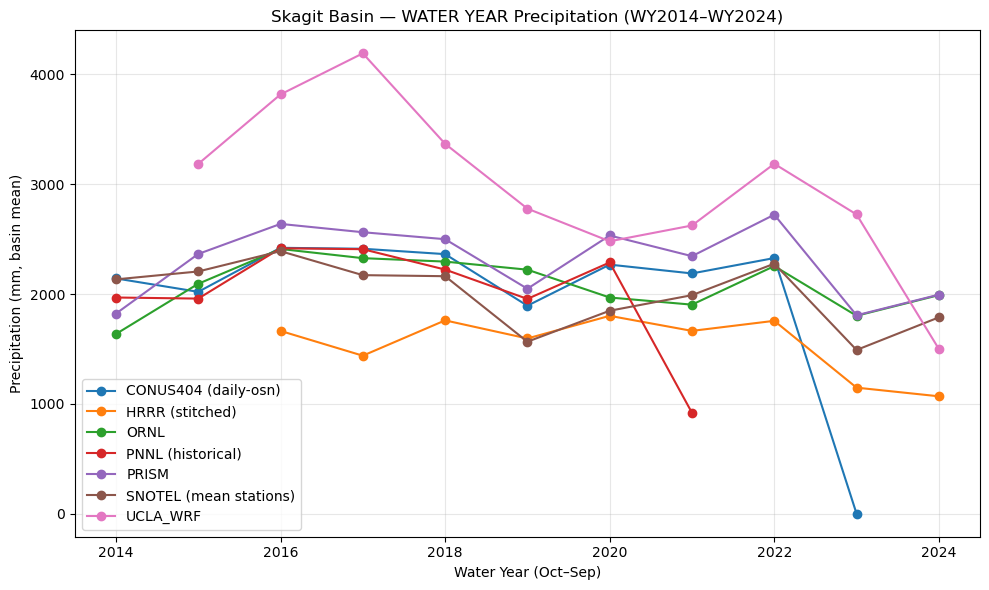

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 → Sep 30, labeled by ending year (WY2014 = 2013-10-01..2014-09-30)
#
# FIXES:
# - HRRR: correct WY month selection + robust concat (precip-only concat + mask from first month)
# - UCLA: correct WY by combining wy-1 and wy yearly zarrs + slicing Oct–Sep
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024   # WATER YEAR labels

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def skagit_mask(ds_with_latlon):
    """Build boolean mask True inside Skagit on dataset's native grid."""
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name": ["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    m = regions.mask(lon, lat)
    return m.isnull() == False

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

def basin_mean(da, grid_ds=None):
    """Basin mean using Skagit mask on native grid."""
    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    if "time" not in da.dims:
        return xr.DataArray(da).rename("mm")
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            bm = basin_mean(da, grid_ds=dso)
            bm = bm.sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))
            ann = water_year_sum_mm(bm)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(ann, wy)
                if not np.isnan(val):
                    rows.append({"dataset": "ORNL", "year": wy, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            bm = basin_mean(da, grid_ds=dsp)
            bm = bm.sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))
            ann = water_year_sum_mm(bm)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(ann, wy)
                if not np.isnan(val):
                    rows.append({"dataset": "PRISM", "year": wy, "mm": val})

# ======================================================================
# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + correct mask)
# Replaces previous HRRR block
# Strategy:
#   - Select WY months: Oct–Dec (wy-1) + Jan–Sep (wy)
#   - Use ds0 = first month FULL dataset to build mask (keeps lon/lat)
#   - Concat precip-only datasets across months to avoid longitude conflicts
# ======================================================================
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])

        # ds0: full dataset for mask-building (must retain lon/lat variables)
        ds0 = safe_open_zarr(parts[0])

        # decide var based on ds0 (consistent across months)
        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        # open precip-only dataset for each month to avoid MergeError on longitude/latitude
        dsets = []
        ok = True
        for p in parts:
            dsm = safe_open_zarr(p)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {p.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])  # keep only precip variable

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        # concat precip-only datasets
        ds = xr.concat(
            dsets,
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        ).sortby("time")

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)      # increments in mm (or deaccum if cumulative)
        daily = hourly_mm.resample(time="1D").sum()          # daily totals (mm/day)
        bm = basin_mean(daily, grid_ds=ds0)                  # USE ds0 for proper mask
        bm = ensure_time_sorted_unique(bm)
        bm = bm.sel(time=slice(wy_start(wy), wy_end(wy)))

        val = float(bm.sum("time", skipna=True).values)
        rows.append({"dataset": "HRRR (stitched)", "year": wy, "mm": val})
        print(f"[HRRR] WY{wy}: {val:.1f} mm")

        # close handles
        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")
# ======================================================================

# ---------- UCLA WRF (WY-correct: combine wy-1 and wy zarrs, then slice Oct–Sep) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    year_to_zarr = {}
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        if m:
            year_to_zarr[int(m.group(1))] = z

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        z_prev = year_to_zarr.get(wy - 1)
        z_curr = year_to_zarr.get(wy)
        if z_prev is None or z_curr is None:
            print(f"[UCLA_WRF] WY{wy}: missing {wy-1} or {wy} zarr -> skipping")
            continue

        ds_prev = safe_open_zarr(z_prev)
        ds_curr = safe_open_zarr(z_curr)

        dsw = xr.concat(
            [ds_prev, ds_curr],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override"
        ).sortby("time")

        v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            print(f"[UCLA_WRF] WY{wy}: no RAINNC/RAINC -> skipping")
            continue

        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)
                total = inc if total is None else total + inc

        total = ensure_time_sorted_unique(total)
        total = total.sel(time=slice(wy_start(wy), wy_end(wy)))

        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        val = float(bm.sum("time", skipna=True).values)

        rows.append({"dataset": "UCLA_WRF", "year": wy, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"

    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            yearly_values = {}
            base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                    continue

                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN-1}-10-01": f"{YEAR_MAX}-09-30"]

                wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                annual = tmp.groupby("wy")["mm"].sum()

                for wy, val in annual.items():
                    wy = int(wy)
                    if YEAR_MIN <= wy <= YEAR_MAX:
                        yearly_values.setdefault(wy, []).append(float(val))

            if yearly_values:
                for wy in sorted(yearly_values.keys()):
                    mm_mean = float(np.nanmean(np.array(yearly_values[wy], dtype="float64")))
                    rows.append({"dataset": "SNOTEL (mean stations)", "year": wy, "mm": mm_mean})

# ---------- PNNL (historical; hourly PREC_ACC_NC → WY total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        if not files:
            continue

        dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        Pwy = p.sum(dim="time").values
        if Pwy.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: {Pwy.shape} vs mask {Skmask.shape}")

        rows.append({"dataset": "PNNL (historical)", "year": wy, "mm": float(Pwy[Skmask].mean())})
        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))

        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))

        skagit_daily = precip.where(mask_da).mean(dim=("y", "x"))

        skagit_wy = water_year_sum_mm(skagit_daily)
        for wy in range(YEAR_MIN, YEAR_MAX + 1):
            val = pick_wy(skagit_wy, wy)
            if not np.isnan(val):
                rows.append({"dataset": "CONUS404 (daily-osn)", "year": wy, "mm": float(val)})

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

plt.figure(figsize=(10, 6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Water Year (Oct–Sep)")
plt.ylabel("Precipitation (mm, basin mean)")
plt.title(f"Skagit Basin — WATER YEAR Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] DJF 2014: missing months ['2013-12', '2014-01', '2014-02'] -> skipping
[HRRR] DJF 2015: 546.1 mm
[HRRR] DJF 2016: 795.5 mm
[HRRR] DJF 2017: 471.4 mm
[HRRR] DJF 2018: 719.0 mm
[HRRR] DJF 2019: 690.3 mm
[HRRR] DJF 2020: 933.4 mm
[HRRR] DJF 2021: 790.0 mm
[HRRR] DJF 2022: 608.9 mm
[HRRR] DJF 2023: 544.0 mm
[HRRR] DJF 2024: 386.1 mm
[HRRR] MAM 2014: missing months ['2014-03', '2014-04', '2014-05'] -> skipping
[HRRR] MAM 2015: 248.9 mm
[HRRR] MAM 2016: 281.2 mm
[HRRR] MAM 2017: 389.4 mm
[HRRR] MAM 2018: 337.0 mm
[HRRR] MAM 2019: 216.9 mm
[HRRR] MAM 2020: 299.1 mm
[HRRR] MAM 2021: 197.8 mm
[HRRR] MAM 2022: 376.2 mm
[HRRR] MAM 2023: 217.8 mm
[HRRR] MAM 2024: 263.1 mm
[HRRR] JJA 2014: missing months ['2014-06', '2014-07', '2014-08'] -> skipping
[HRRR] JJA 2015: 88.3 mm
[HRRR] JJA 2016: 133.9 mm
[HRRR] JJA 2017: 46.2 mm
[HRRR] JJA 2018: 70.0 mm
[HRRR] JJA 2019: 141.6 mm
[HRRR] JJA 2020: 164.3 mm
[HRRR] JJA 2021: 65.2 mm
[HRRR] JJA 2022: 

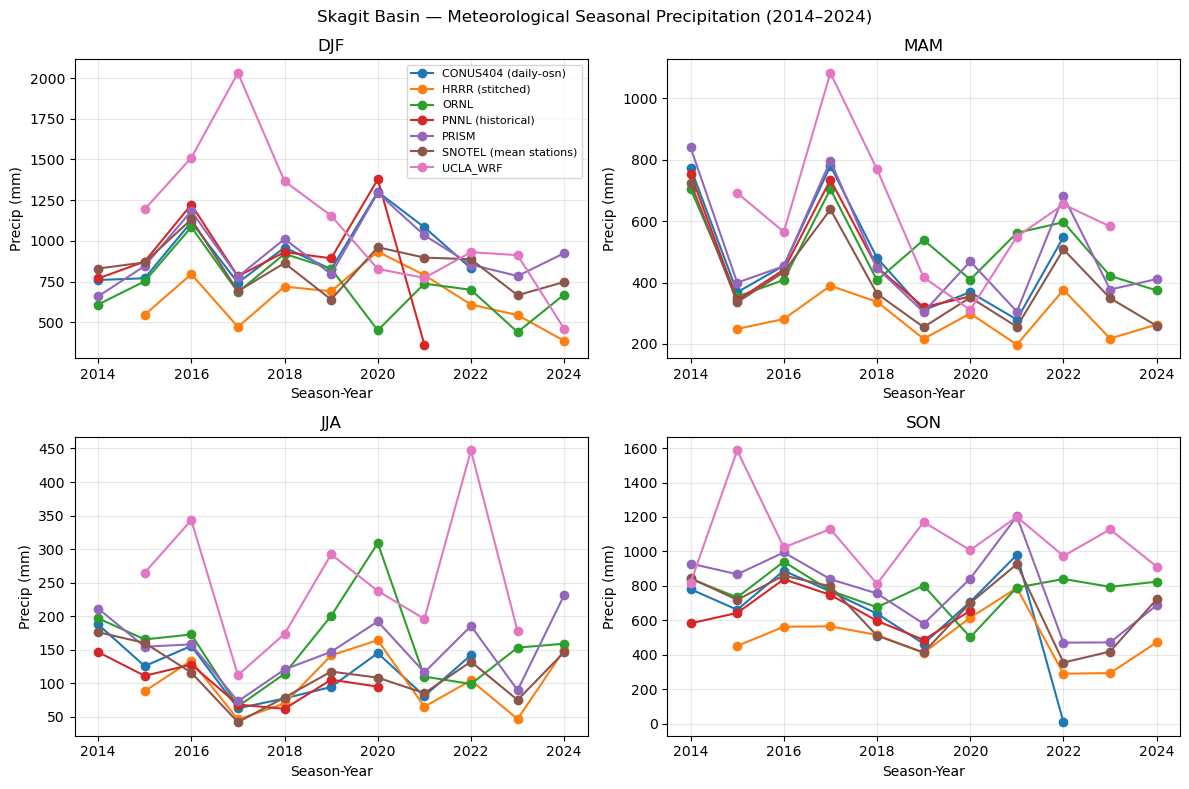

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)  - labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / f"met_season_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def skagit_mask(ds_with_latlon):
    """Build boolean mask True inside Skagit on dataset's native grid."""
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name": ["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    m = regions.mask(lon, lat)
    return m.isnull() == False

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

def basin_mean(da, grid_ds=None):
    """Basin mean using Skagit mask on native grid."""
    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def season_year_index(time_da, season_label):
    """DJF labeled by ending year (Dec -> y+1). Others labeled by calendar year."""
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        return xr.where(m == 12, y + 1, y)
    return y

def seasonal_sum_mm(da, season_label):
    """Sum over a meteorological season grouped by season-year."""
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None
    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_year(ann, year):
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: year}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    """Return ISO start/end strings (inclusive slice) for season-year.
    DJF year is labeled by ending year (DJF 2014 = 2013-12-01..2014-02-lastday)
    """
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_season_year(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

# ---------------- Collectors ----------------
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ---------- ORNL ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat([safe_open_zarr(p) for p in ornl_years],
                        dim="time", join="outer", coords="minimal", compat="override")
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            bm = basin_mean(da, grid_ds=dso).sel(time=slice(GLOBAL_START, GLOBAL_END))
            for s in SEASONS.keys():
                ann = seasonal_sum_mm(bm, s)
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    val = pick_year(ann, yr)
                    if not np.isnan(val):
                        rows.append({"dataset": "ORNL", "season": s, "year": yr, "mm": val})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat([safe_open_zarr(p) for p in prism_years],
                        dim="time", join="outer", coords="minimal", compat="override")
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            bm = basin_mean(da, grid_ds=dsp).sel(time=slice(GLOBAL_START, GLOBAL_END))
            for s in SEASONS.keys():
                ann = seasonal_sum_mm(bm, s)
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    val = pick_year(ann, yr)
                    if not np.isnan(val):
                        rows.append({"dataset": "PRISM", "season": s, "year": yr, "mm": val})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need = hrrr_month_prefixes_for_season_year(yr, s)
            missing = sorted(list(need - available))
            if missing:
                print(f"[HRRR] {s} {yr}: missing months {missing} -> skipping")
                continue

            parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
            ds0 = safe_open_zarr(parts[0])

            var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
            if not var:
                print(f"[HRRR] {s} {yr}: no tp/apcp in {parts[0].name} -> skipping")
                try: ds0.close()
                except Exception: pass
                continue

            dsets = []
            ok = True
            for p in parts:
                dsm = safe_open_zarr(p)
                if var not in dsm:
                    print(f"[HRRR] {s} {yr}: {p.name} missing {var} -> skipping")
                    try: dsm.close()
                    except Exception: pass
                    ok = False
                    break
                dsets.append(dsm[[var]])

            if not ok:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
            if hourly_mm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            daily = hourly_mm.resample(time="1D").sum()
            bm = basin_mean(daily, grid_ds=ds0)
            bm = ensure_time_sorted_unique(bm)

            t0, t1 = season_time_window(yr, s)
            bm = bm.sel(time=slice(t0, t1))
            if bm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            val = float(bm.sum("time", skipna=True).values)
            rows.append({"dataset": "HRRR (stitched)", "season": s, "year": yr, "mm": val})
            print(f"[HRRR] {s} {yr}: {val:.1f} mm")

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- UCLA WRF ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    year_to_zarr = {}
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        if m:
            year_to_zarr[int(m.group(1))] = z

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need_years = {yr}
            if s == "DJF":
                need_years.add(yr - 1)

            missing_years = [y for y in sorted(need_years) if y not in year_to_zarr]
            if missing_years:
                print(f"[UCLA_WRF] {s} {yr}: missing years {missing_years} -> skipping")
                continue

            dsets = [safe_open_zarr(year_to_zarr[y]) for y in sorted(need_years)]
            dsw = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
            v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
            if not (v_nc or v_c):
                print(f"[UCLA_WRF] {s} {yr}: no RAINNC/RAINC -> skipping")
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                continue

            total = None
            for vv in [v_nc, v_c]:
                if vv:
                    inc = to_incremental_mm(dsw[vv], force_cumulative=True)
                    total = inc if total is None else total + inc

            total = ensure_time_sorted_unique(total)
            t0, t1 = season_time_window(yr, s)
            total = total.sel(time=slice(t0, t1))
            if total.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                continue

            daily = total.resample(time="1D").sum()
            bm = basin_mean(daily, grid_ds=dsw)
            val = float(bm.sum("time", skipna=True).values)

            rows.append({"dataset": "UCLA_WRF", "season": s, "year": yr, "mm": val})

            for d in dsets:
                try: d.close()
                except Exception: pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
            seasonal_values = {}

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                    continue

                precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                idx = precip_mm.index

                month = idx.month.to_numpy()
                year_arr = idx.year.to_numpy()

                season = np.full(len(idx), "", dtype=object)
                season[np.isin(month, [12, 1, 2])] = "DJF"
                season[np.isin(month, [3, 4, 5])] = "MAM"
                season[np.isin(month, [6, 7, 8])] = "JJA"
                season[np.isin(month, [9, 10, 11])] = "SON"

                season_year = year_arr.copy()
                dec_mask = (season == "DJF") & (month == 12)
                season_year[dec_mask] = season_year[dec_mask] + 1

                tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                tmp = tmp[(tmp["year"] >= YEAR_MIN) & (tmp["year"] <= YEAR_MAX)]
                tmp = tmp[tmp["season"].isin(SEASONS.keys())]

                agg = tmp.groupby(["season", "year"])["mm"].sum()
                for (ss, yy), val in agg.items():
                    seasonal_values.setdefault((ss, int(yy)), []).append(float(val))

            for (ss, yy), vals in seasonal_values.items():
                rows.append({"dataset": "SNOTEL (mean stations)", "season": ss, "year": yy, "mm": float(np.nanmean(vals))})

# ---------- PNNL ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            years_needed = {yr}
            if s == "DJF":
                years_needed.add(yr - 1)

            files = []
            for yy in sorted(years_needed):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            if not files:
                continue

            dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)
            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            t0, t1 = season_time_window(yr, s)
            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            P = p.sum(dim="time").values
            if P.shape != Skmask.shape:
                raise ValueError(f"[PNNL] Shape mismatch: {P.shape} vs mask {Skmask.shape}")

            rows.append({"dataset": "PNNL (historical)", "season": s, "year": yr, "mm": float(P[Skmask].mean())})
            dsp.close()

# ---------- CONUS404 ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))

        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))

        skagit_daily = precip.where(mask_da).mean(dim=("y", "x"))

        for s in SEASONS.keys():
            ann = seasonal_sum_mm(skagit_daily, s)
            for yr in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_year(ann, yr)
                if not np.isnan(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "season": s, "year": yr, "mm": float(val)})

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# One figure: 4 panels (one per season) comparing datasets
seasons_order = ["DJF","MAM","JJA","SON"]

plt.figure(figsize=(12, 8))
for i, s in enumerate(seasons_order, start=1):
    plt.subplot(2, 2, i)
    dss = df[df["season"] == s]
    for name, g in dss.groupby("dataset"):
        plt.plot(g["year"], g["mm"], marker="o", label=name)
    plt.title(s)
    plt.xlabel("Season-Year")
    plt.ylabel("Precip (mm)")
    plt.grid(True, alpha=0.3)
    if i == 1:
        plt.legend(fontsize=8)

plt.suptitle(f"Skagit Basin — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()


[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: 1664.5 mm
[HRRR] WY2017: 1438.8 mm
[HRRR] WY2018: 1760.5 mm
[HRRR] WY2019: 1595.7 mm
[HRRR] WY2020: 1801.8 mm
[HRRR] WY2021: 1664.8 mm
[HRRR] WY2022: 1756.4 mm
[HRRR] WY2023: 1147.9 mm
[HRRR] WY2024: 1069.1 mm
[UCLA_WRF] WY2014: missing 2013 or 2014 zarr -> skipping
[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...
[SNOTEL] Using stations:
  - Beaver Pass (990_WA_SNTL)
  - Brown Top (1080_WA_SNTL)
  - Marten Ridge (999_WA_SNTL)
  - Rainy Pass (711_WA_SNTL)
  - Swamp Creek (975_WA_SNTL)
  - Thunder Basin (817_WA_SNTL)
[CONUS404] Loading from HyTEST (conus404-daily-osn)...
                 dataset  year           mm
0   CONUS404 (daily-osn)  2014  2142.

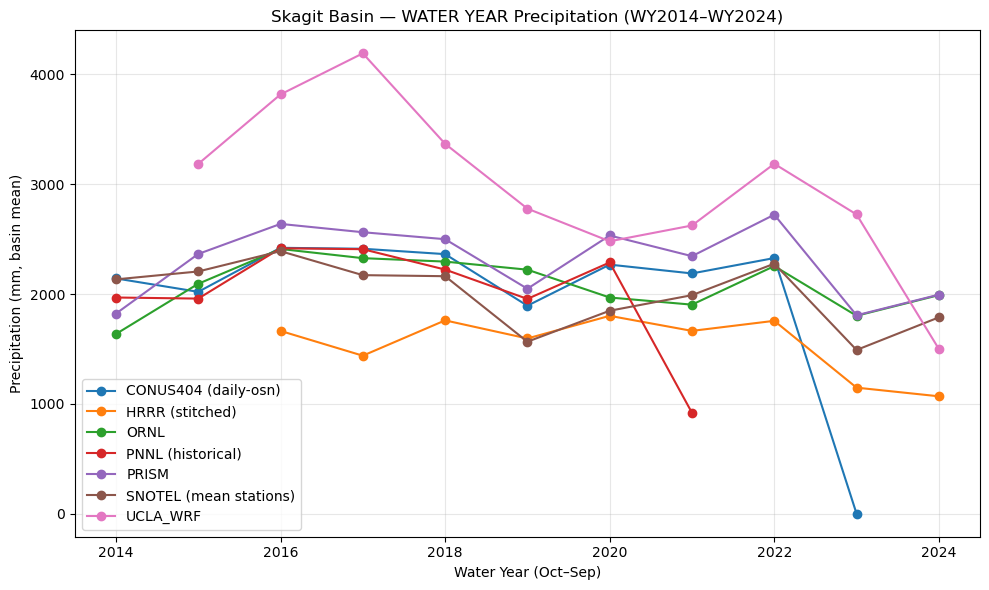


[MAE vs PRISM] Per water year (mm):
    year                 dataset      mae_mm
0   2014    CONUS404 (daily-osn)  320.737480
1   2014         HRRR (stitched)         NaN
2   2014                    ORNL  185.659636
3   2014       PNNL (historical)  146.917656
4   2014  SNOTEL (mean stations)  311.920895
..   ...                     ...         ...
61  2024         HRRR (stitched)  925.577008
62  2024                    ORNL    4.049909
63  2024       PNNL (historical)         NaN
64  2024  SNOTEL (mean stations)  206.847196
65  2024                UCLA_WRF  494.405321

[66 rows x 3 columns]
Saved MAE CSV → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_2014_2024.csv
Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_2014_2024.png


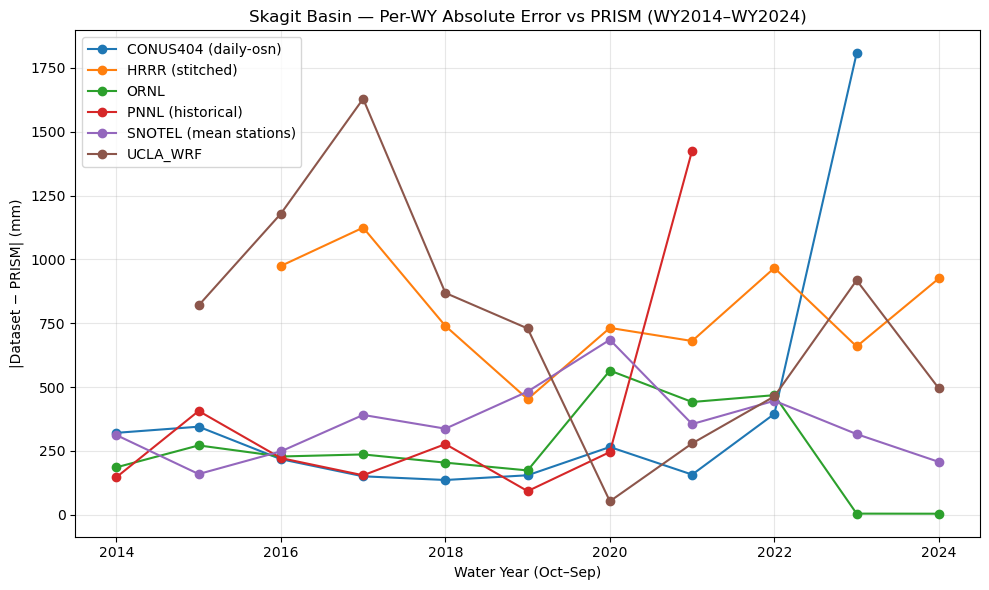

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 to Sep 30, labeled by ending year (WY2014 = 2013-10-01..2014-09-30)
#
# FIXES:
# - HRRR: correct WY month selection + robust concat (precip-only concat + mask from first month)
# - UCLA: correct WY by combining wy-1 and wy yearly zarrs + slicing Oct–Sep
#
# ADD:
# - Per-WY absolute error (MAE per year) vs PRISM for all other datasets
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")

YEAR_MIN, YEAR_MAX = 2014, 2024   # WATER YEAR labels

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"water_year_precip_skagit_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

# NEW outputs
MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_{YEAR_MIN}_{YEAR_MAX}.png"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def skagit_mask(ds_with_latlon):
    """Build boolean mask True inside Skagit on dataset's native grid."""
    try:
        import regionmask, geopandas as gpd
    except Exception:
        return None

    lat_name, lon_name = find_lat_lon_names(ds_with_latlon)
    if not (lat_name and lon_name):
        return None

    def _to_2d(arr):
        if "time" in arr.dims:
            arr = arr.isel(time=0)
        for d in list(arr.dims):
            if arr.sizes[d] == 1:
                arr = arr.isel({d: 0})
        while arr.ndim > 2:
            extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
            if not extra:
                break
            arr = arr.isel({extra[0]: 0})
        return arr

    lon = _to_2d(ds_with_latlon[lon_name])
    lat = _to_2d(ds_with_latlon[lat_name])

    from shapely.geometry import shape
    with open(BOUNDARY_GEO) as f:
        obj = json.load(f)
    if obj.get("type") == "FeatureCollection":
        geom = shape(obj["features"][0]["geometry"])
    elif obj.get("type") == "Feature":
        geom = shape(obj["geometry"])
    else:
        geom = shape(obj)

    try:
        regions = regionmask.Regions.from_geopandas(
            gpd.GeoDataFrame({"name": ["Skagit"]}, geometry=[geom], crs="EPSG:4326"),
            names="name",
        )
    except AttributeError:
        regions = regionmask.Regions(outlines=[geom], names=["Skagit"], numbers=[0], name="Skagit")

    m = regions.mask(lon, lat)
    return m.isnull() == False

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

def basin_mean(da, grid_ds=None):
    """Basin mean using Skagit mask on native grid."""
    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        return da

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    mask = skagit_mask(host)
    if (mask is None) or (set(mask.dims) != set(spatial)):
        return da.mean(spatial, skipna=True)

    w = xr.where(mask, 1.0, np.nan)
    return (da * w).mean(spatial, skipna=True)

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    if "time" not in da.dims:
        return xr.DataArray(da).rename("mm")
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
rows = []

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            bm = basin_mean(da, grid_ds=dso)
            bm = bm.sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))
            ann = water_year_sum_mm(bm)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(ann, wy)
                if not np.isnan(val):
                    rows.append({"dataset": "ORNL", "year": wy, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            bm = basin_mean(da, grid_ds=dsp)
            bm = bm.sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))
            ann = water_year_sum_mm(bm)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(ann, wy)
                if not np.isnan(val):
                    rows.append({"dataset": "PRISM", "year": wy, "mm": val})

# ======================================================================
# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + correct mask)
# ======================================================================
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])

        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for p in parts:
            dsm = safe_open_zarr(p)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {p.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(
            dsets,
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        ).sortby("time")

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=ds0)
        bm = ensure_time_sorted_unique(bm)
        bm = bm.sel(time=slice(wy_start(wy), wy_end(wy)))

        val = float(bm.sum("time", skipna=True).values)
        rows.append({"dataset": "HRRR (stitched)", "year": wy, "mm": val})
        print(f"[HRRR] WY{wy}: {val:.1f} mm")

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")
# ======================================================================

# ---------- UCLA WRF (WY-correct: combine wy-1 and wy zarrs, then slice Oct–Sep) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    year_to_zarr = {}
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        if m:
            year_to_zarr[int(m.group(1))] = z

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        z_prev = year_to_zarr.get(wy - 1)
        z_curr = year_to_zarr.get(wy)
        if z_prev is None or z_curr is None:
            print(f"[UCLA_WRF] WY{wy}: missing {wy-1} or {wy} zarr -> skipping")
            continue

        ds_prev = safe_open_zarr(z_prev)
        ds_curr = safe_open_zarr(z_curr)

        dsw = xr.concat(
            [ds_prev, ds_curr],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override"
        ).sortby("time")

        v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            print(f"[UCLA_WRF] WY{wy}: no RAINNC/RAINC -> skipping")
            continue

        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)
                total = inc if total is None else total + inc

        total = ensure_time_sorted_unique(total)
        total = total.sel(time=slice(wy_start(wy), wy_end(wy)))

        daily = total.resample(time="1D").sum()
        bm = basin_mean(daily, grid_ds=dsw)
        val = float(bm.sum("time", skipna=True).values)

        rows.append({"dataset": "UCLA_WRF", "year": wy, "mm": val})

# ---------- SNOTEL (GitHub egagli repo; mean of Skagit stations) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"

    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            print("[SNOTEL] Using stations:")
            for _, row in skagit_stations.iterrows():
                print(f"  - {row['name']} ({row['code']})")

            yearly_values = {}
            base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

            for _, row in skagit_stations.iterrows():
                code = row["code"]
                name = row["name"]
                csv_url = f"{base_csv_url}/{code}.csv"

                try:
                    df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                except Exception as e:
                    print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                    continue

                if "PRCPSA" not in df_s.columns:
                    print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                    continue

                precip_mm = df_s["PRCPSA"] * 1000.0
                precip_mm = precip_mm.loc[f"{YEAR_MIN-1}-10-01": f"{YEAR_MAX}-09-30"]

                wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                annual = tmp.groupby("wy")["mm"].sum()

                for wy, val in annual.items():
                    wy = int(wy)
                    if YEAR_MIN <= wy <= YEAR_MAX:
                        yearly_values.setdefault(wy, []).append(float(val))

            if yearly_values:
                for wy in sorted(yearly_values.keys()):
                    mm_mean = float(np.nanmean(np.array(yearly_values[wy], dtype="float64")))
                    rows.append({"dataset": "SNOTEL (mean stations)", "year": wy, "mm": mm_mean})

# ---------- PNNL (historical; hourly PREC_ACC_NC - WY total with fixed mask) ----------
PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].values.astype(bool)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        if not files:
            continue

        dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        Pwy = p.sum(dim="time").values
        if Pwy.shape != Skmask.shape:
            raise ValueError(f"[PNNL] Shape mismatch: {Pwy.shape} vs mask {Skmask.shape}")

        rows.append({"dataset": "PNNL (historical)", "year": wy, "mm": float(Pwy[Skmask].mean())})
        dsp.close()

# ---------- CONUS404 (daily-osn; HyTEST via intake) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(f"{YEAR_MIN-1}-10-01", f"{YEAR_MAX}-09-30"))

        gdf = gpd.read_file(BOUNDARY_GEO)
        geom = gdf.geometry.iloc[0]

        lat = ds["lat"]
        lon = ds["lon"]
        mask_np = shapely.contains_xy(geom, lon.values, lat.values)
        mask_da = xr.DataArray(mask_np, dims=("y", "x"))

        skagit_daily = precip.where(mask_da).mean(dim=("y", "x"))

        skagit_wy = water_year_sum_mm(skagit_daily)
        for wy in range(YEAR_MIN, YEAR_MAX + 1):
            val = pick_wy(skagit_wy, wy)
            if not np.isnan(val):
                rows.append({"dataset": "CONUS404 (daily-osn)", "year": wy, "mm": float(val)})

# ---------------- Results: WY totals ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

plt.figure(figsize=(10, 6))
for name, g in df.groupby("dataset"):
    plt.plot(g["year"], g["mm"], marker="o", label=name)
plt.xlabel("Water Year (Oct–Sep)")
plt.ylabel("Precipitation (mm, basin mean)")
plt.title(f"Skagit Basin — WATER YEAR Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-WY MAE (absolute error) vs PRISM
#   Since there is ONE value per WY, "MAE per year" == |err|
# ==========================================================
wide = df.pivot(index="year", columns="dataset", values="mm")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

# Absolute error per year per dataset vs PRISM
abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()

# Drop PRISM itself
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

# Long-form MAE table: (year, dataset, mae_mm)
mae_long = (
    abs_err.reset_index()
           .melt(id_vars="year", var_name="dataset", value_name="mae_mm")
           .sort_values(["year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per water year (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot: abs error vs PRISM per year
plt.figure(figsize=(10, 6))
for name in abs_err.columns:
    plt.plot(abs_err.index, abs_err[name], marker="o", label=name)

plt.xlabel("Water Year (Oct–Sep)")
plt.ylabel(f"|Dataset − {MAE_REF}| (mm)")
plt.title(f"Skagit Basin — Per-WY Absolute Error vs {MAE_REF} (WY{YEAR_MIN}–WY{YEAR_MAX})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE plot →", MAE_PNG_OUT)
plt.show()


In [ ]:
# ---------- PNNL (historical) — FIXED: units + deaccum + memory-safe ----------
# Uses Skagit mask on PNNL grid, then basin-mean and seasonal total (mm).
# Drops partial seasons based on missing MONTHS if you want.

PNNL_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_mask_pnnl_450x450.nc")
DROP_PARTIAL_MONTHS = True  #  months-based

def expected_months_for_season(season_label):
    return set(SEASONS[season_label])  # {12,1,2} etc.

def months_present_in_times(times):
    if len(times) == 0:
        return set()
    tt = pd.to_datetime(times)
    return set(np.unique(tt.month))

if PNNL_HIST.exists() and PNNL_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_MASK)
    Skmask = mask_ds["skagit_mask"].astype(bool)  # keep as DataArray (dims matter)
    mask_ds.close()

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            t0, t1 = season_time_window(yr, s)

            years_needed = {yr}
            if s == "DJF":
                years_needed.add(yr - 1)

            files = []
            for yy in sorted(years_needed):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            files = sorted(files)
            if not files:
                continue

            prev_last = None
            seen_months = set()
            season_total_mm = 0.0  # basin-mean seasonal total (mm)

            for fp in files:
                ds = xr.open_dataset(fp, engine="netcdf4", chunks={"time": 24 * 7})
                if "PREC_ACC_NC" not in ds:
                    ds.close()
                    continue

                da_cum = ensure_time_sorted_unique(ds["PREC_ACC_NC"]).sel(time=slice(t0, t1))
                if da_cum.sizes.get("time", 0) == 0:
                    ds.close()
                    continue

                # --- units sanity (convert cum to mm if needed) ---
                units = str(da_cum.attrs.get("units", "")).lower().strip()
                # common: "mm" or "" ; sometimes "m" or "kg m-2"
                if units in {"m", "meter", "meters", "metre", "metres"}:
                    da_cum = da_cum * 1000.0
                    da_cum.attrs["units"] = "mm"
                elif ("kg" in units and "m" in units and "-2" in units) or (units == "kg m-2"):
                    # precip mass per area ~ mm of water
                    da_cum.attrs["units"] = "mm"

                # month coverage
                seen_months |= months_present_in_times(da_cum["time"].values)

                # --- deaccumulate with file-boundary carry ---
                da0 = da_cum.isel(time=0)
                if prev_last is None:
                    first_inc = da0 * 0.0
                else:
                    first_inc = (da0 - prev_last).clip(min=0)

                dif = da_cum.diff("time", label="upper").clip(min=0)
                inc = xr.concat([first_inc.expand_dims(time=[da_cum["time"].values[0]]), dif], dim="time")
                prev_last = da_cum.isel(time=-1)

                # hourly - daily
                inc_daily = inc.resample(time="1D").sum()

                # --- basin mean on native grid mask, then sum time ---
                # Important: make mask dims match inc_daily spatial dims by name.
                spatial_dims = [d for d in inc_daily.dims if d != "time"]
                if list(Skmask.dims) != spatial_dims:
                    # rename mask dims by position (safe for (y,x)/(south_north,west_east) variations)
                    Skmask_aligned = xr.DataArray(Skmask.values, dims=spatial_dims)
                else:
                    Skmask_aligned = Skmask

                basin_daily = inc_daily.where(Skmask_aligned).mean(spatial_dims, skipna=True)
                season_total_mm += float(basin_daily.sum("time", skipna=True).compute().values)

                ds.close()

            # --- drop partial seasons by missing MONTHS (not days) ---
            if DROP_PARTIAL_MONTHS:
                need = expected_months_for_season(s)
                if not need.issubset(seen_months):
                    missing = sorted(list(need - seen_months))
                    print(f"[PNNL] SKIP {s} {yr}: missing months {missing} (seen={sorted(seen_months)})")
                    continue

            rows.append({"dataset": "PNNL (historical)", "season": s, "year": yr, "mm": float(season_total_mm)})
            print(f"[PNNL] {s} {yr}: basin_mean_total={season_total_mm:.1f} mm")
else:
    print("[PNNL] Skipping PNNL: missing PNNL_HIST or mask file.")


NameError: name 'Path' is not defined